In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation")  # <<< updated path here to refer to the implementation of OT-Impute and other imputation methods
import utils
import Inject_Missing_Values
import Updated_OT
import imputers
import imputers_fullyActive

In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from Inject_Missing_Values import *
from imputers import OTimputer #original OT imputer
from Updated_OT import OTimputerDropOutNoise #dropout noise imputer
from imputers_fullyActive import OTimputerFullyActive # fully activeOT

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)

### Disease Data

Loading the data

In [5]:
data = fetch_openml(name="diabetes", version=1, as_frame=True)
X_full = data.data.copy()

In [6]:
# Convert categorical to numerical codes
for col in X_full.select_dtypes(include=['category', 'object']).columns:
    X_full[col] = X_full[col].astype('category').cat.codes

In [7]:
scaler = MinMaxScaler() #data [0,1]
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [8]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [10]:
GroundTruth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
dtypes: float64(8)
memory usage: 48.1 KB


In [12]:
GroundTruth.nunique()

preg     17
plas    136
pres     47
skin     51
insu    186
mass    248
pedi    517
age      52
dtype: int64

Dependecies for MAR & MNAR

In [14]:
mean_age = GroundTruth["age"].mean()
mean_preg = GroundTruth["preg"].mean()
mean_plas = GroundTruth["plas"].mean()
median_pres = GroundTruth["pres"].median()
median_skin = GroundTruth["skin"].median()
mean_insu = GroundTruth["insu"].mean()
mean_mass = GroundTruth["mass"].mean()
median_pedi = GroundTruth["pedi"].median()

dependencies_mar = {
    "preg": {
        "influencers": ["plas"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["plas"] >= mean_plas else 0.1
    },
    "plas": {
        "influencers": ["mass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["mass"] <= mean_mass else 0.1
    },
    "pres": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] >= mean_age else 0.1
    },
    "skin": {
        "influencers": ["pres"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pres"] <= median_pres else 0.1
    },
    "insu": {
        "influencers": ["preg"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["preg"] >= mean_preg else 0.1
    },
    "mass": {
        "influencers": ["pedi"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pedi"] >= median_pedi else 0.1
    },
    "pedi": {
        "influencers": ["skin"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["skin"] <= median_skin else 0.1
    },
    "age": {
        "influencers": ["insu"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["insu"] >= mean_insu else 0.1
    }
}


In [15]:
mean_preg = GroundTruth["preg"].mean()
mean_plas = GroundTruth["plas"].mean()
median_pres = GroundTruth["pres"].median()
median_skin = GroundTruth["skin"].median()
mean_insu = GroundTruth["insu"].mean()
mean_mass = GroundTruth["mass"].mean()
median_pedi = GroundTruth["pedi"].median()
mean_age = GroundTruth["age"].mean()


dependencies_mnar = {
    "preg": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["preg"] >= mean_preg else 0.1
    },
    "plas": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["plas"] < mean_plas else 0.1
    },
    "pres": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pres"] <= median_pres else 0.1
    },
    "skin": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["skin"] >= median_skin else 0.1
    },
    "insu": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["insu"] > mean_insu else 0.1
    },
    "mass": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["mass"] <= mean_mass else 0.1
    },
    "pedi": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pedi"] >= median_pedi else 0.1
    },
    "age": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] > mean_age else 0.1
    }
}


## Running OT-Impute, OT-Rand & Batch-Impute

## MCAR

In [16]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing
budgets = [0.1, 0.2, 0.3]  # Query 10%, 25%, 50% of missing cells

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}


for missing_rate in missing_rates:
    generator_mcar = Inject_Missing_Values() #missing value generating
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()

    

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mcar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mcar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mcar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mcar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mcar[metric]:
        for method in results_mcar[metric][budget]:
            values = results_mcar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mcar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mcar = df_results_mcar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mcar.columns.name = None
df_results_mcar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mcar.columns]
df_results_mcar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_results_mcar_metrics.csv", index=False)
    

  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 


Plotting results...


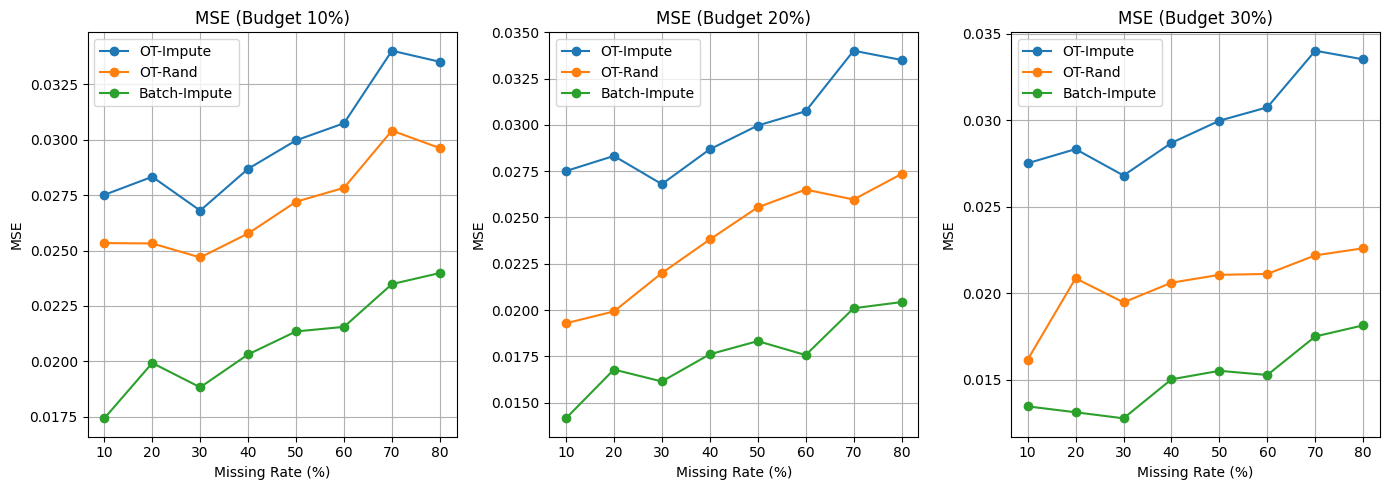

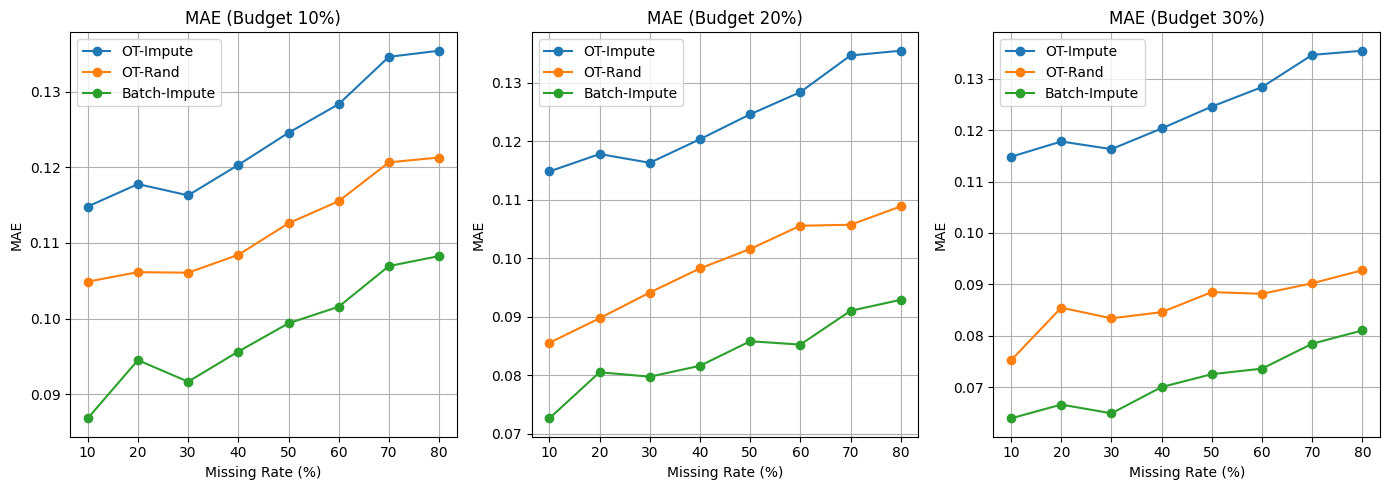

In [17]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

## MAR

In [18]:
results_mar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    total_missing_percentage_mar = miss_mar.isnull().sum().sum() / miss_mar.size * 100
    print(f"Total Missing Percentage MAR: {total_missing_percentage_mar:.2f}%")

    missing_percentage = (miss_mar.isnull().sum() / len(miss_mar)) * 100
    print(missing_percentage)

    missing_mask = miss_mar.isna()

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mar[metric]:
        for method in results_mar[metric][budget]:
            values = results_mar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mar = df_results_mar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mar.columns.name = None
df_results_mar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mar.columns]
df_results_mar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_results_mar_metrics.csv", index=False)
    

Total Missing Percentage MAR: 9.99%
preg    12.109375
plas     9.375000
pres     8.463542
skin     9.635417
insu    10.026042
mass    10.546875
pedi    10.156250
age      9.635417
dtype: float64
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
Total Missing Percentage MAR: 19.99%
preg    22.005208
plas    21.093750
pres    16.276042
skin    20.182292
insu    19.661458
mass    20.442708
pedi    21.744792
age     18.489583
dtype: float64
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
Total Missing Percentage MAR: 30.00%
preg    31.380208
plas    31.640625
pres    25.130208
skin    31.250000
insu    30.468750
mass    30.989583
pedi    33.072917
age     26.041667
dtype: float64
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4.


Plotting results...


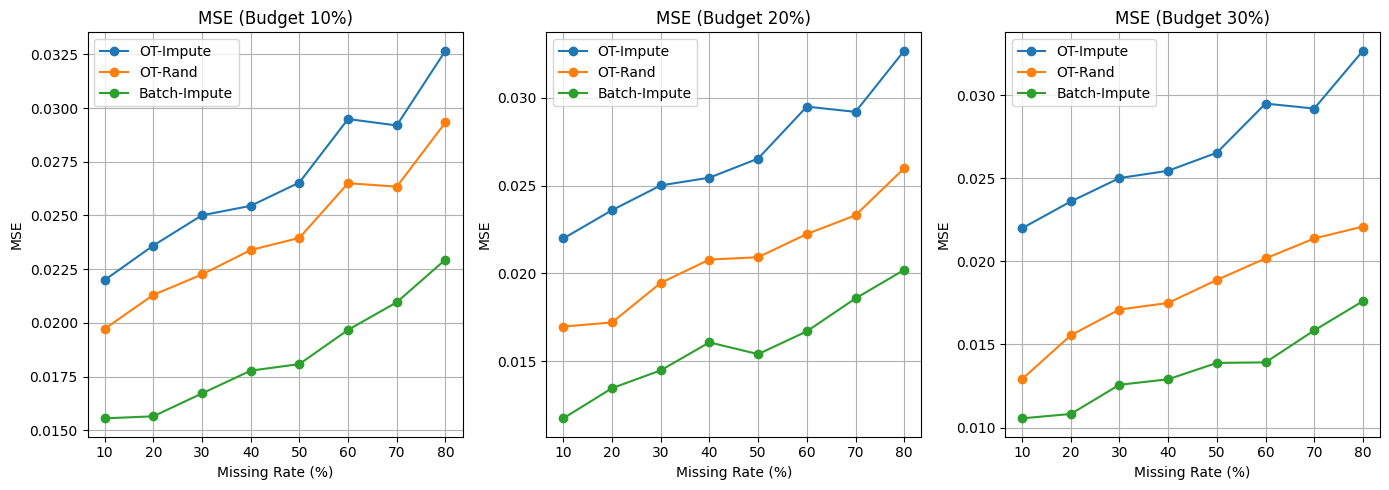

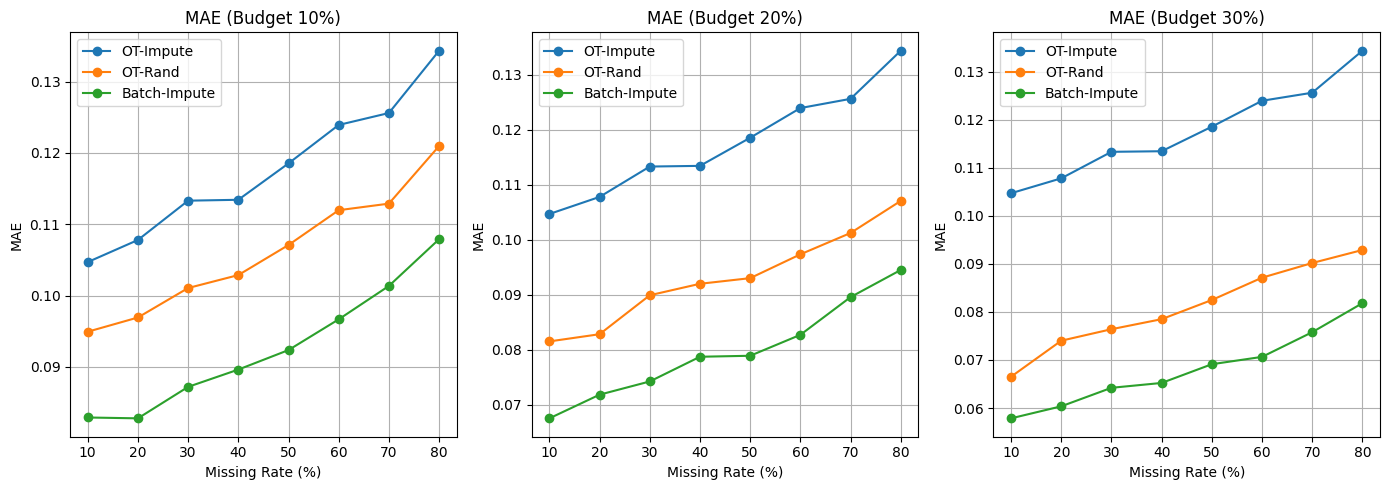

In [19]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

## MNAR

In [20]:
results_mnar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mnar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mnar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mnar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mnar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mnar[metric]:
        for method in results_mnar[metric][budget]:
            values = results_mnar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mnar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mnar = df_results_mnar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mnar.columns.name = None
df_results_mnar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mnar.columns]
df_results_mnar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_results_mnar_metrics.csv", index=False)
    

  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 


Plotting results...


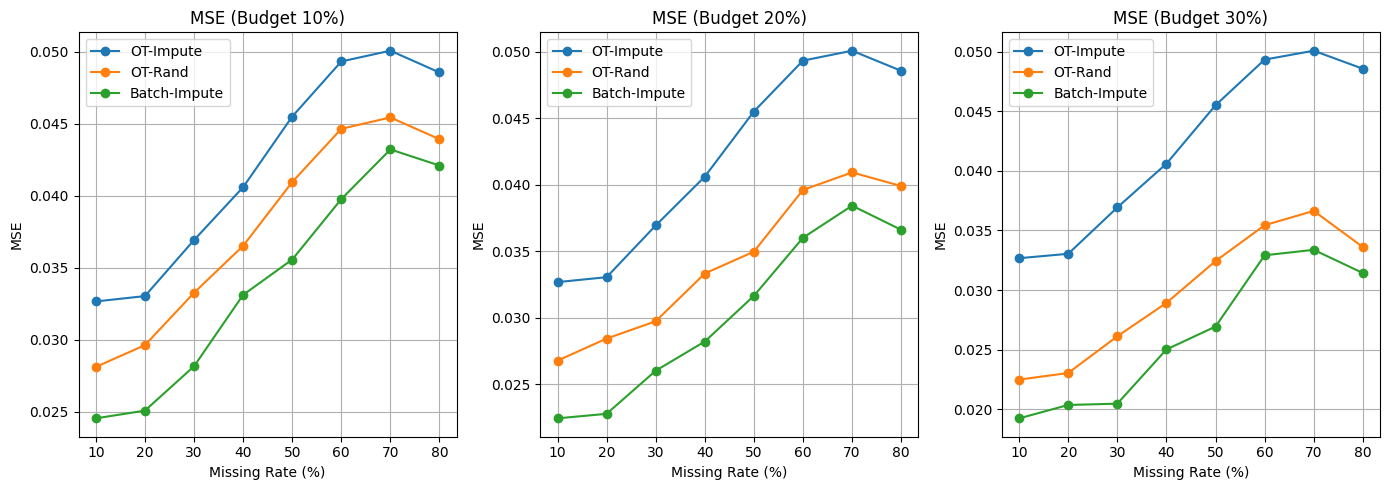

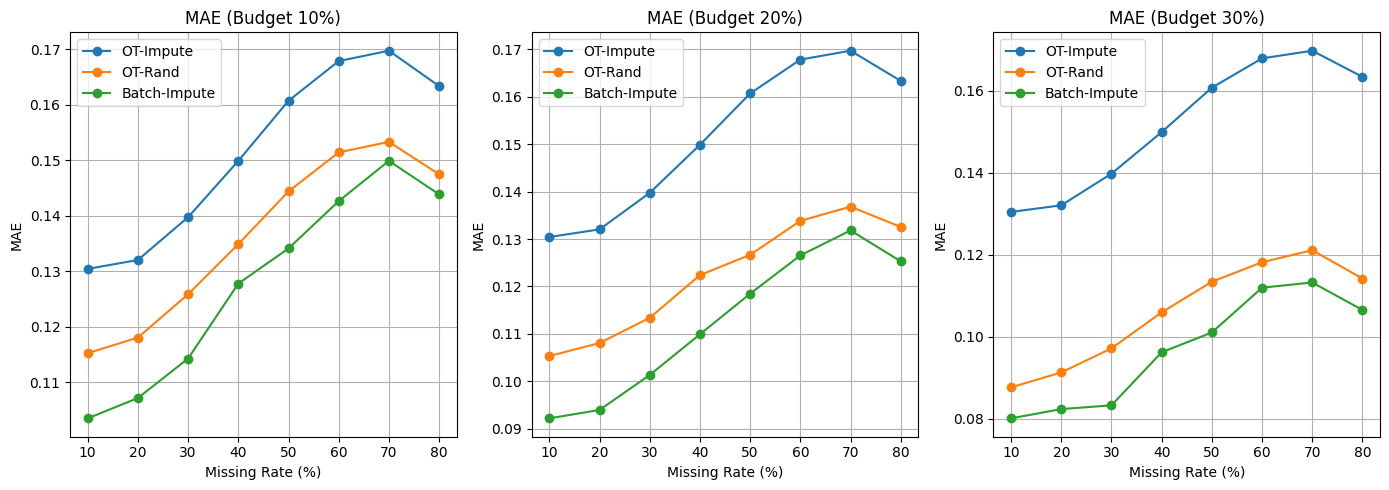

In [21]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

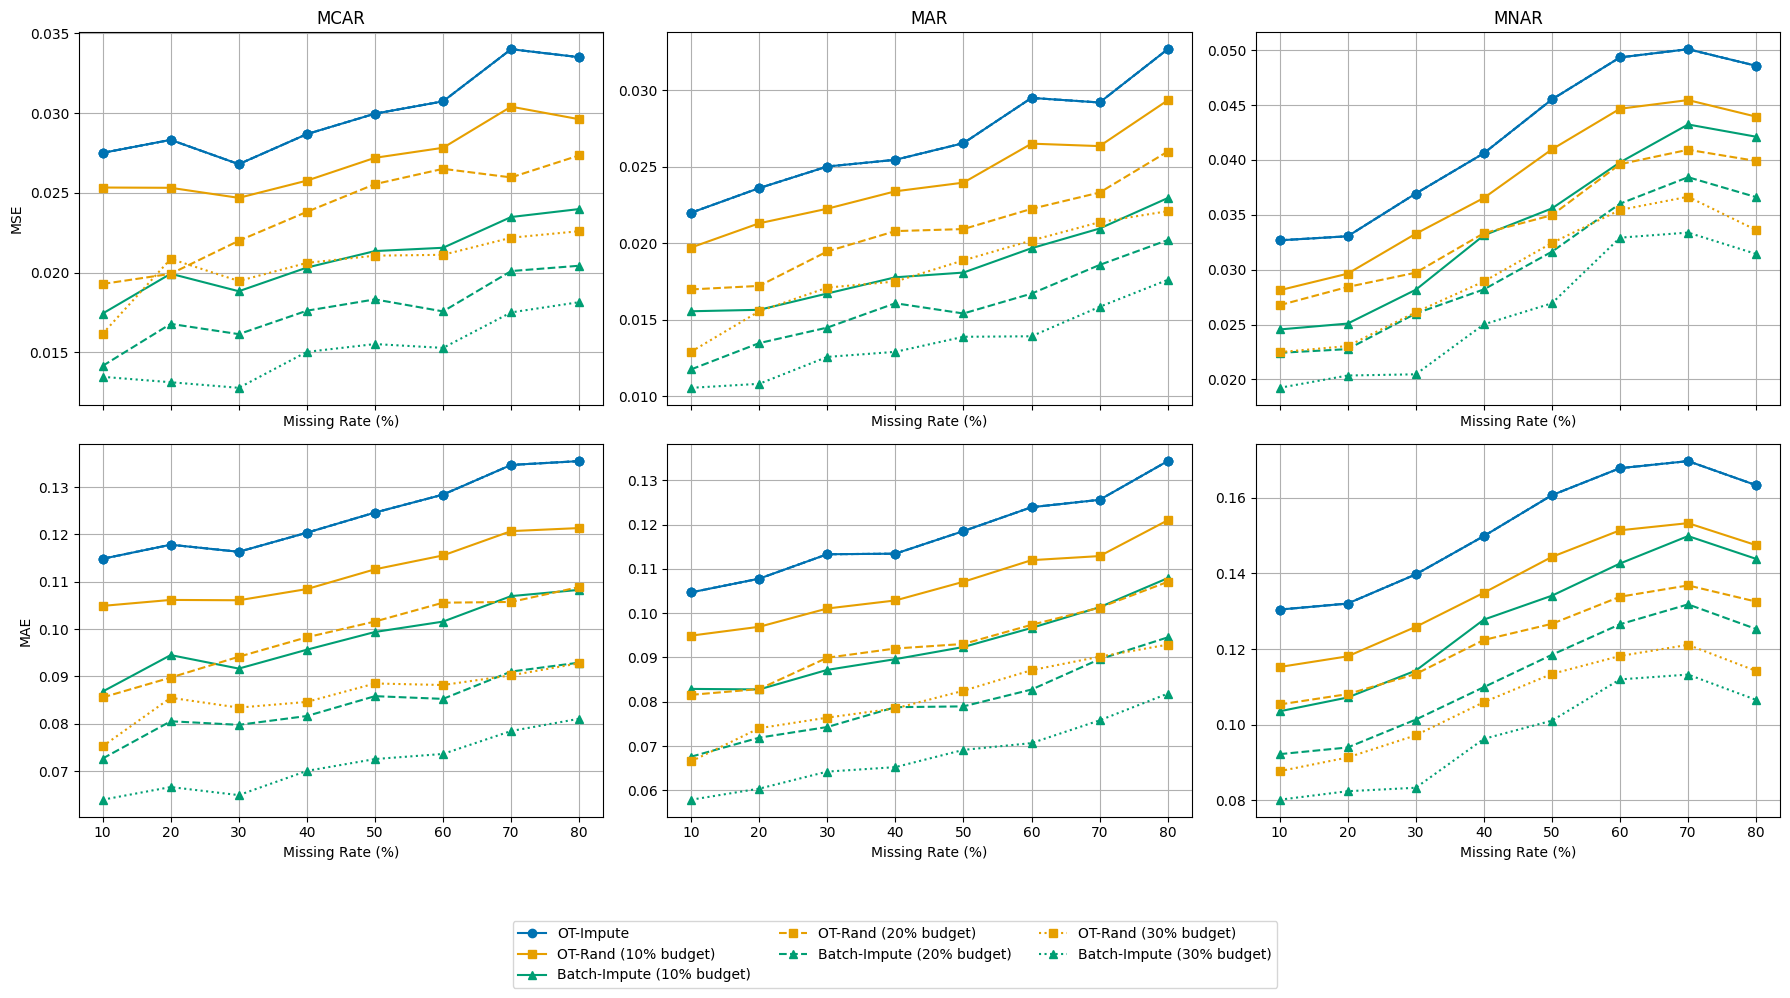

In [22]:
import matplotlib.pyplot as plt

# === Data Setup (replace these with your real data) ===
# Each pattern result should follow this format:
# results_*[metric]["budget_fraction"]["method"] = list of values
pattern_data = {
    "MCAR": results_mcar,
    "MAR": results_mar,
    "MNAR": results_mnar
}

missing_patterns = ["MCAR", "MAR", "MNAR"]
budgets = [0.1, 0.2, 0.3]
methods = ["OT-Impute", "OT-Rand", "Batch-Impute"]
missing_rates = [10, 20, 30, 40, 50, 60, 70, 80]  # Adjust as needed

# === Style Settings ===
line_styles = {0.1: '-', 0.2: '--', 0.3: ':'}
markers = {"OT-Impute": 'o', "OT-Rand": 's', "Batch-Impute": '^'}
colors = {"OT-Impute": '#0072B2', "OT-Rand": '#E69F00', "Batch-Impute": '#009E73'}  # colorblind-friendly

# === Optional: std values for error bands ===
# Format: std_data[pattern][metric][budget][method] = list of stds
# Set to None if not using
std_data = None  # or load your std_data dictionary here

# === Plotting ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

metrics = ["MSE", "MAE"]

vanilla_labeled = False

for row_idx, metric in enumerate(metrics):
    for col_idx, pattern in enumerate(missing_patterns):
        ax = axes[row_idx, col_idx]
    
        results = pattern_data[pattern]

        for budget in budgets:
            for method in methods:
                plot_method = "Batch-Impute" if method == "Batch-Impute" else method
                values = results[metric][budget][plot_method]

                if len(values) != len(missing_rates):
                    print(f"⚠️ Skipped: {pattern}, {metric}, {method}, budget {budget}")
                    continue

                # Plot mean line
                if method == "OT-Impute":
                    label = "OT-Impute" if not vanilla_labeled else None
                    vanilla_labeled = True
                else:
                    label = f"{method} ({int(budget * 100)}% budget)"

                

                ax.plot(
                    missing_rates,
                    values,
                    linestyle=line_styles[budget],
                    marker=markers[method],
                    color=colors[method],
                    label=label
                )


                # Optional: Error bands
                if std_data:
                    std_vals = std_data[pattern][metric][budget][method]
                    if len(std_vals) == len(values):
                        lower = [v - s for v, s in zip(values, std_vals)]
                        upper = [v + s for v, s in zip(values, std_vals)]
                        ax.fill_between(missing_rates, lower, upper, color=colors[method], alpha=0.2)

        if row_idx == 0:
            ax.set_title(pattern)
        if col_idx == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("Missing Rate (%)")
        ax.grid(True)

# === Shared Legend ===
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', bbox_to_anchor=(0.5, -0.05))

# === Main Title & Layout ===

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_matrix.pdf", bbox_inches='tight')

plt.show()


## Comarision with Baseline

MCAR Budget 0.1

In [23]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=300, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mcar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mcar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mcar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mcar_b01 = pd.DataFrame(all_results_comparision_mcar_b01)
df_comparision_mcar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_mae_base_comparison_mcar_budget01_allruns.csv",
    index=False
)


===== RUN 1 / 5 =====

=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0818
     OT-Rand 0.0945
        MICE 0.0970
   OT-Impute 0.1022
         KNN 0.1044
        Mean 0.1182

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0900
     OT-Rand 0.0980
        MICE 0.1046
         KNN 0.1144
   OT-Impute 0.1184
        Mean 0.1221

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0902
     OT-Rand 0.1039
   OT-Impute 0.1152
        MICE 0.1184
         KNN 0.1214
        Mean 0.1216

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0968
     OT-Rand 0.1144
         KNN 0.1234
        Mean 0.1247
   OT-Impute 0.1260
        MICE 0.1268

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0968
     OT-Rand 0.1149
   OT-Impute 0.1222
        Mean 0.1226
         KNN 0.1259
        MICE 0.1314

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1018
     OT-Rand 0.1173
        MICE 0.1223
        Mean 0.1235
         KNN 0.1253
   OT-Impute 0.1284

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1034
     OT-Rand 0.1176
        Mean 0.1233
        MICE 0.1258
         KNN 0.1268
   OT-Impute 0.1295

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Meth

...

Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1026
     OT-Rand 0.1145
        MICE 0.1225
        Mean 0.1238
         KNN 0.1245
   OT-Impute 0.1276

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1060
     OT-Rand 0.1193
        Mean 0.1232
        MICE 0.1246
         KNN 0.1249
   OT-Impute 0.1310

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1089
     OT-Rand 0.1191
        Mean 0.1224
        MICE 0.1232
         KNN 0.1248
   OT-Impute 0.1329

===== RUN 5 / 5 =====

=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE

c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0968
     OT-Rand 0.1109
   OT-Impute 0.1223
        Mean 0.1254
         KNN 0.1288
        MICE 0.1313

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0982
     OT-Rand 0.1096
        Mean 0.1233
   OT-Impute 0.1247
         KNN 0.1262
        MICE 0.1309

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1022
     OT-Rand 0.1165
        Mean 0.1236
        MICE 0.1237
         KNN 0.1269
   OT-Impute 0.1282

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1032
     OT-Rand 0.1177
        Mean 0.1233
         KNN 0.1251
        MICE 0.1252
   OT-Impute 0.1308

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Meth

MAR

In [24]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=300, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mar_b01 = pd.DataFrame(all_results_comparision_mar_b01)
df_comparision_mar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_mae_base_comparison_mar_budget01_allruns.csv",
    index=False
)


===== RUN 1 / 5 =====

=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0805
     OT-Rand 0.0901
        MICE 0.0934
         KNN 0.1034
   OT-Impute 0.1037
        Mean 0.1177

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0855
     OT-Rand 0.0944
   OT-Impute 0.1037
        MICE 0.1048
         KNN 0.1171
        Mean 0.1195

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0871
     OT-Rand 0.0998
   OT-Impute 0.1123
        Mean 0.1186
        MICE 0.1259
         KNN 0.1314

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0898
     OT-Rand 0.1046
   OT-Impute 0.1147
        Mean 0.1212
        MICE 0.1298
         KNN 0.1336

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


...

Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0883
     OT-Rand 0.0955
   OT-Impute 0.1105
        Mean 0.1186
        MICE 0.1259
         KNN 0.1314

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0908
     OT-Rand 0.1021
   OT-Impute 0.1120
        Mean 0.1212
        MICE 0.1298
         KNN 0.1336

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0923
     OT-Rand 0.1043
   OT-Impute 0.1157
        Mean 0.1219
        MICE 0.1254
         KNN 0.1338

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.0977
     OT-Rand 0.1103
   OT-Impute 0.1229
        MICE 0.1233
        Mean 0.1241
         KNN 0.1259

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1016
     OT-Rand 0.1156
         KNN 0.1225
        Mean 0.1246
        MICE 0.1257
   OT-Impute 0.1259

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Meth

MNAR

In [25]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mnar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=300, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mnar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mnar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mnar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mnar_b01 = pd.DataFrame(all_results_comparision_mnar_b01)
df_comparision_mnar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_mae_base_comparison_mnar_budget01_allruns.csv",
    index=False
)


===== RUN 1 / 5 =====

=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1019
        MICE 0.1162
     OT-Rand 0.1178
         KNN 0.1196
   OT-Impute 0.1305
        Mean 0.1329

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1079
        MICE 0.1195
     OT-Rand 0.1227
         KNN 0.1269
   OT-Impute 0.1325
        Mean 0.1364

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1133
     OT-Rand 0.1253
        MICE 0.1352
         KNN 0.1369
   OT-Impute 0.1397
        Mean 0.1415

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1243
     OT-Rand 0.1349
        MICE 0.1434
         KNN 0.1438
        Mean 0.1476
   OT-Impute 0.1491

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


...

Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1150
     OT-Rand 0.1272
        MICE 0.1352
         KNN 0.1369
   OT-Impute 0.1396
        Mean 0.1415

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1241
     OT-Rand 0.1382
        MICE 0.1434
         KNN 0.1438
        Mean 0.1476
   OT-Impute 0.1503

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1321
     OT-Rand 0.1432
        MICE 0.1476
         KNN 0.1539
        Mean 0.1546
   OT-Impute 0.1618

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1430
     OT-Rand 0.1509
        MICE 0.1558
         KNN 0.1613
        Mean 0.1638
   OT-Impute 0.1694

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1489
     OT-Rand 0.1548
        MICE 0.1645
        Mean 0.1663
         KNN 0.1679
   OT-Impute 0.1719

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Meth

## Optimization

### MAE vd Dropout noise for BatchOpt-Impute MCAR

In [26]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05,
                 0.1]



results_mcar_opt_dropOut = {d: [] for d in dropOutNoises}
n_runs = 10  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mcar = Inject_Missing_Values()
        miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
        missing_mask = miss_mcar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mcar_opt_dropOut[dropOutNoise].append(mae)





# Flatten results into a list of records
records_mcar_dropOut = []

for noise, maes in results_mcar_opt_dropOut.items():
    for run_id, mae in enumerate(maes):
        records_mcar_dropOut.append({
            "DropoutNoise": noise,
            "Run": run_id + 1,
            "MAE": mae
        })

# Convert to DataFrame
df_results = pd.DataFrame(records_mcar_dropOut)

# Save to CSV
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MCAR_DropoutNoise_MAE_Results.csv", index=False)
print("Results saved to DropoutNoise_MAE_Results.csv")




=== Dropout Noise: 0.0 ===
  Run 1/10


  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 1e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 5e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.01 ===
  Run 1/10
  Run 2/10
 

### MAE vd Dropout noise for BatchOpt-Impute MAR

In [27]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05,
                 0.1]



results_mar_opt_dropOut = {d: [] for d in dropOutNoises}
n_runs = 10  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mar = Inject_Missing_Values()
        miss_mar, index_mar = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
        missing_mask = miss_mar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mar_opt_dropOut[dropOutNoise].append(mae)





# Flatten results into a list of records
records_mar_dropOut = []

for noise, maes in results_mar_opt_dropOut.items():
    for run_id, mae in enumerate(maes):
        records_mar_dropOut.append({
            "DropoutNoise": noise,
            "Run": run_id + 1,
            "MAE": mae
        })

# Convert to DataFrame
df_results = pd.DataFrame(records_mar_dropOut)

# Save to CSV
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MAR_DropoutNoise_MAE_Results.csv", index=False)





=== Dropout Noise: 0.0 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 1e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 5e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout 

### MAE vd Dropout noise for BatchOpt-Impute MNAR

In [28]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05,
                 0.1]



results_mnar_opt_dropOut = {d: [] for d in dropOutNoises}
n_runs = 10  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mnar = Inject_Missing_Values()
        miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
        missing_mask = miss_mnar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mnar_opt_dropOut[dropOutNoise].append(mae)





# Flatten results into a list of records
records_mnar_dropOut = []

for noise, maes in results_mnar_opt_dropOut.items():
    for run_id, mae in enumerate(maes):
        records_mnar_dropOut.append({
            "DropoutNoise": noise,
            "Run": run_id + 1,
            "MAE": mae
        })

# Convert to DataFrame
df_results = pd.DataFrame(records_mnar_dropOut)

# Save to CSV
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MNAR_DropoutNoise_MAE_Results.csv", index=False)
print("Results saved to DropoutNoise_MAE_Results.csv")




=== Dropout Noise: 0.0 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 1e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 5e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout 

MCAR

In [29]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mcar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mcar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mcar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mcar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)


# Save MAE results
mae_df = pd.DataFrame(results_mcar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MCAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mcar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MCAR_OPT_Results_Time.csv", index=False)









=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===


MAR

In [30]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    missing_mask = miss_mar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)


# Save MAE results
mae_df = pd.DataFrame(results_mar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MAR_OPT_Results_Time.csv", index=False)









=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===


MNAR

In [31]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mnar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mnar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mnar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mnar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mnar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mnar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mnar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mnar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mnar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mnar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mnar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)


# Save MAE results
mae_df = pd.DataFrame(results_mnar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MNAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mnar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MNAR_OPT_Results_Time.csv", index=False)



=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===


## Fully Active

MCAR

In [32]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X, missing_rate=30)
mask = X_missing.isna()
missing_pos = np.argwhere(mask.values)

results_fullyActive_mcar = []
max_k = 15
budget_fractions = [0.1, 0.2, 0.3]

for budget_fraction in budget_fractions:
    print(f"\n===== Running for Budget Fraction: {budget_fraction} =====")
    budget = int(budget_fraction * len(missing_pos))

    for k in range(1, max_k + 1):
        print(f"\nRunning iterative ActiveFix with k={k} steps...")
        start = time.time()
        current_X = X_missing.copy()
        fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
        budget_per_iter = budget // k

        if budget_per_iter == 0:
            print(f"  Skipping k={k} (budget too small per iteration)")
            continue

        intermediate_mae = []
        unique_queried_cells = set()
        avg_std_per_iteration = []

        for step in range(k):
            print(f"  Iteration {step+1}/{k}...")

            # Start from the original missing data with fixed values filled in
            initial_X = X_missing.values.copy()
            initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

            # Run OTimputer 4 times to obtain aggregated imputed values
            X_runs = []
            for _ in range(4):
                Xt = torch.tensor(initial_X, dtype=torch.float64)
                X_imp = OTimputerFullyActive(niter=100, batchsize=64).fit_transform(Xt).detach().numpy()
                X_runs.append(X_imp)

            # Aggregate the imputed values (mean and std)
            X_stack = np.stack(X_runs)
            X_mean = np.mean(X_stack, axis=0)
            X_std = np.std(X_stack, axis=0)

            # Update the imputed values with the aggregated mean, keeping fixed values intact
            current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

            # Identify uncertain cells not fixed yet
            candidates = np.argwhere(mask.values & ~fixed_mask)
            std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

            # Sort the standard deviations in descending order and select the top uncertain cells
            top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
            selected_pos = candidates[top_idx]

            # Update unique queried cells and average std for this iteration
            unique_queried_cells.update([tuple(pos) for pos in selected_pos])
            avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
            avg_std_per_iteration.append(avg_std)

            print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
            print(f"    X_std (max value): {np.max(X_std)}")
            print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

            # Query the oracle and update the dataset
            if selected_pos.size > 0:
                rows, cols = zip(*selected_pos)
                current_X.values[rows, cols] = GroundTruth.values[rows, cols]
                fixed_mask[rows, cols] = True  # Mark these cells as fixed

            # Calculate intermediate MAE after each iteration
            mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
            intermediate_mae.append(mae_iter)
            print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

        elapsed = time.time() - start
        mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        num_unique = len(unique_queried_cells)
        avg_std_total = np.mean(avg_std_per_iteration)

        results_fullyActive_mcar.append({
            'k': k,
            'BudgetFraction': budget_fraction,
            'MAE': mae,
            'Runtime': elapsed,
            'UniqueQueried': num_unique,
            'AvgStdQueried': avg_std_total
        })
        print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar = pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)

df_iter_mcar = pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)

# Save the results to CSV
df_iter_mcar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MCAR.csv", index=False)
print("Results saved to German_iterative_activeFix_results.csv.")



===== Running for Budget Fraction: 0.1 =====

Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 1843
    X_std (max value): 0.24330051043094594
    Avg Std of Queried Cells: 0.1530
    Intermediate MAE after iteration 1: 0.0961
  Final MAE: 0.0961, Time: 62.99s, Unique Queried: 184, Avg Std: 0.1530

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 1843
    X_std (max value): 0.21789863916853106
    Avg Std of Queried Cells: 0.1664
    Intermediate MAE after iteration 1: 0.0998
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT impute

MAR

In [ ]:
generator_mar = Inject_Missing_Values()
X_missing, index_mar = generator_mar.MAR(X, missing_rate=30,dependencies=dependencies_mar)
mask = X_missing.isna()
missing_pos = np.argwhere(mask.values)

results_fullyActive_mar = []
max_k = 15
budget_fractions = [0.1, 0.2, 0.3]

for budget_fraction in budget_fractions:
    print(f"\n===== Running for Budget Fraction: {budget_fraction} =====")
    budget = int(budget_fraction * len(missing_pos))

    for k in range(1, max_k + 1):
        print(f"\nRunning iterative ActiveFix with k={k} steps...")
        start = time.time()
        current_X = X_missing.copy()
        fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
        budget_per_iter = budget // k

        if budget_per_iter == 0:
            print(f"  Skipping k={k} (budget too small per iteration)")
            continue

        intermediate_mae = []
        unique_queried_cells = set()
        avg_std_per_iteration = []

        for step in range(k):
            print(f"  Iteration {step+1}/{k}...")

            # Start from the original missing data with fixed values filled in
            initial_X = X_missing.values.copy()
            initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

            # Run OTimputer 4 times to obtain aggregated imputed values
            X_runs = []
            for _ in range(4):
                Xt = torch.tensor(initial_X, dtype=torch.float64)
                X_imp = OTimputerFullyActive(niter=100, batchsize=64).fit_transform(Xt).detach().numpy()
                X_runs.append(X_imp)

            # Aggregate the imputed values (mean and std)
            X_stack = np.stack(X_runs)
            X_mean = np.mean(X_stack, axis=0)
            X_std = np.std(X_stack, axis=0)

            # Update the imputed values with the aggregated mean, keeping fixed values intact
            current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

            # Identify uncertain cells not fixed yet
            candidates = np.argwhere(mask.values & ~fixed_mask)
            std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

            # Sort the standard deviations in descending order and select the top uncertain cells
            top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
            selected_pos = candidates[top_idx]

            # Update unique queried cells and average std for this iteration
            unique_queried_cells.update([tuple(pos) for pos in selected_pos])
            avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
            avg_std_per_iteration.append(avg_std)

            print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
            print(f"    X_std (max value): {np.max(X_std)}")
            print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

            # Query the oracle and update the dataset
            if selected_pos.size > 0:
                rows, cols = zip(*selected_pos)
                current_X.values[rows, cols] = GroundTruth.values[rows, cols]
                fixed_mask[rows, cols] = True  # Mark these cells as fixed

            # Calculate intermediate MAE after each iteration
            mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
            intermediate_mae.append(mae_iter)
            print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

        elapsed = time.time() - start
        mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        num_unique = len(unique_queried_cells)
        avg_std_total = np.mean(avg_std_per_iteration)

        results_fullyActive_mar.append({
            'k': k,
            'BudgetFraction': budget_fraction,
            'MAE': mae,
            'Runtime': elapsed,
            'UniqueQueried': num_unique,
            'AvgStdQueried': avg_std_total
        })
        print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)

df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)

# Save the results to CSV
df_iter_mar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MAR.csv", index=False)




===== Running for Budget Fraction: 0.1 =====

Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 1843
    X_std (max value): 0.23859400004224565
    Avg Std of Queried Cells: 0.1486
    Intermediate MAE after iteration 1: 0.0941
  Final MAE: 0.0941, Time: 53.44s, Unique Queried: 184, Avg Std: 0.1486

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 1843
    X_std (max value): 0.22678553371898275
    Avg Std of Queried Cells: 0.1605
    Intermediate MAE after iteration 1: 0.0989
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT impute

MNAR

In [ ]:
generator_mnar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MNAR(X, missing_rate=30,dependencies=dependencies_mnar)
mask = X_missing.isna()
missing_pos = np.argwhere(mask.values)

results_fullyActive_mnar = []
max_k = 15
budget_fractions = [0.1, 0.2, 0.3]

for budget_fraction in budget_fractions:
    print(f"\n===== Running for Budget Fraction: {budget_fraction} =====")
    budget = int(budget_fraction * len(missing_pos))

    for k in range(1, max_k + 1):
        print(f"\nRunning iterative ActiveFix with k={k} steps...")
        start = time.time()
        current_X = X_missing.copy()
        fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
        budget_per_iter = budget // k

        if budget_per_iter == 0:
            print(f"  Skipping k={k} (budget too small per iteration)")
            continue

        intermediate_mae = []
        unique_queried_cells = set()
        avg_std_per_iteration = []

        for step in range(k):
            print(f"  Iteration {step+1}/{k}...")

            # Start from the original missing data with fixed values filled in
            initial_X = X_missing.values.copy()
            initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

            # Run OTimputer 4 times to obtain aggregated imputed values
            X_runs = []
            for _ in range(4):
                Xt = torch.tensor(initial_X, dtype=torch.float64)
                X_imp = OTimputerFullyActive(niter=100, batchsize=64).fit_transform(Xt).detach().numpy()
                X_runs.append(X_imp)

            # Aggregate the imputed values (mean and std)
            X_stack = np.stack(X_runs)
            X_mean = np.mean(X_stack, axis=0)
            X_std = np.std(X_stack, axis=0)

            # Update the imputed values with the aggregated mean, keeping fixed values intact
            current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

            # Identify uncertain cells not fixed yet
            candidates = np.argwhere(mask.values & ~fixed_mask)
            std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

            # Sort the standard deviations in descending order and select the top uncertain cells
            top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
            selected_pos = candidates[top_idx]

            # Update unique queried cells and average std for this iteration
            unique_queried_cells.update([tuple(pos) for pos in selected_pos])
            avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
            avg_std_per_iteration.append(avg_std)

            print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
            print(f"    X_std (max value): {np.max(X_std)}")
            print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

            # Query the oracle and update the dataset
            if selected_pos.size > 0:
                rows, cols = zip(*selected_pos)
                current_X.values[rows, cols] = GroundTruth.values[rows, cols]
                fixed_mask[rows, cols] = True  # Mark these cells as fixed

            # Calculate intermediate MAE after each iteration
            mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
            intermediate_mae.append(mae_iter)
            print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

        elapsed = time.time() - start
        mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        num_unique = len(unique_queried_cells)
        avg_std_total = np.mean(avg_std_per_iteration)

        results_fullyActive_mnar.append({
            'k': k,
            'BudgetFraction': budget_fraction,
            'MAE': mae,
            'Runtime': elapsed,
            'UniqueQueried': num_unique,
            'AvgStdQueried': avg_std_total
        })
        print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)

df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)

# Save the results to CSV
df_iter_mnar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MNAR.csv", index=False)




Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2741122672710596
    Avg Std of Queried Cells: 0.1462
    Intermediate MAE after iteration 1: 0.1782
  Final MAE: 0.1782, Time: 29.53s, Unique Queried: 20513, Avg Std: 0.1462

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2629870274483607
    Avg Std of Queried Cells: 0.1597
    Intermediate MAE after iteration 1: 0.1881
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-

## Visualization

MAE vs Missingness among OT-Impute, OT-Rand, Batch-Impute

MCAR

Plotting results...
Saved plot for budget 10%


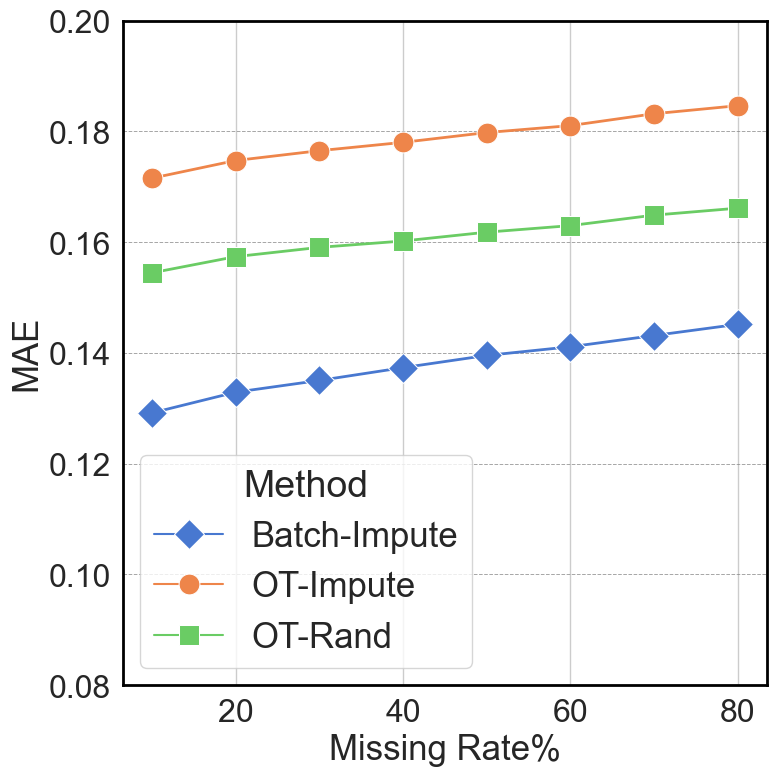

Saved plot for budget 20%


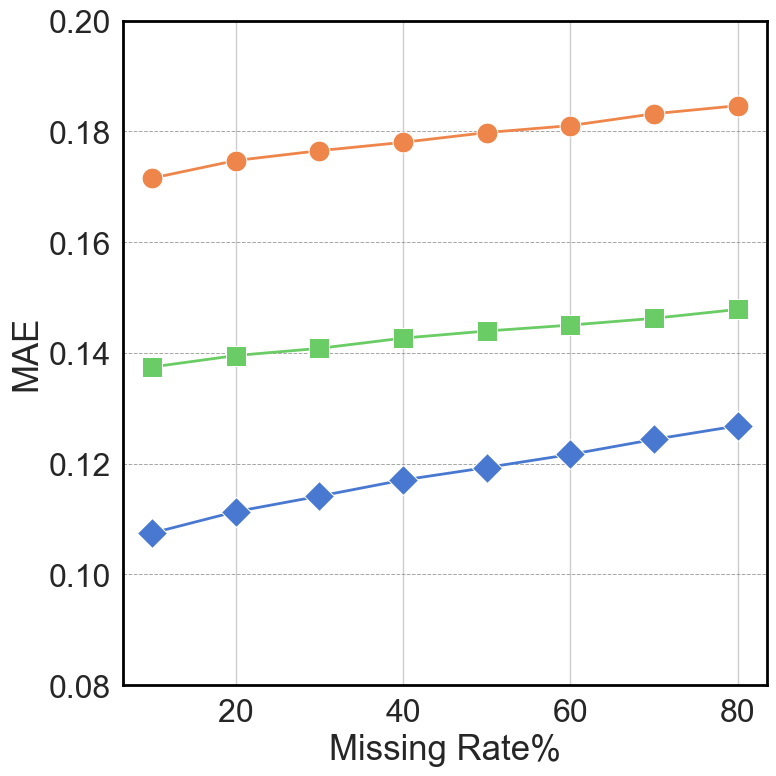

Saved plot for budget 30%


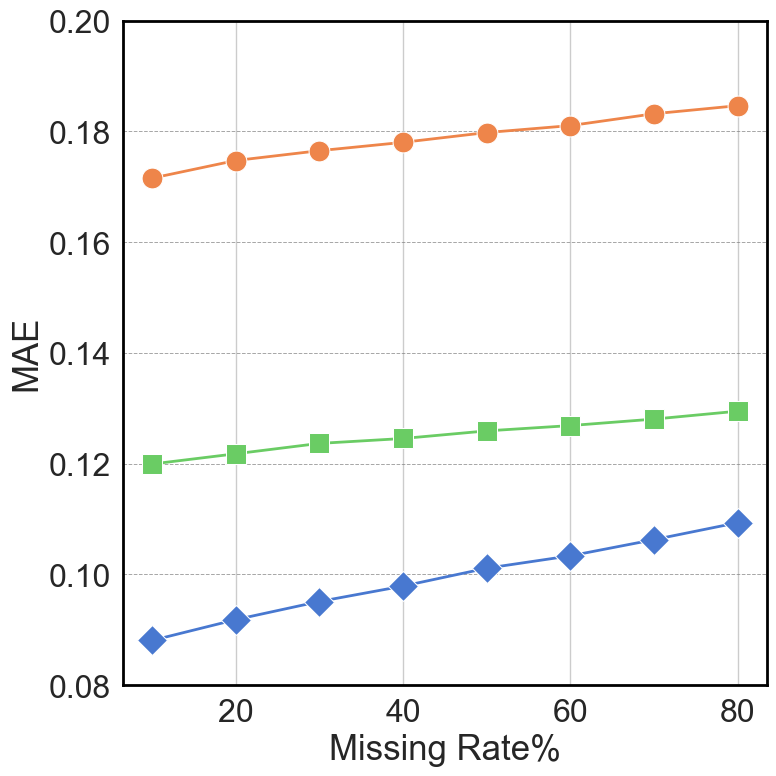

All plots generated successfully.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_results_mcar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.08
y_max = 0.20

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate%", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MCAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

MAR

Plotting results...
Saved plot for budget 10%


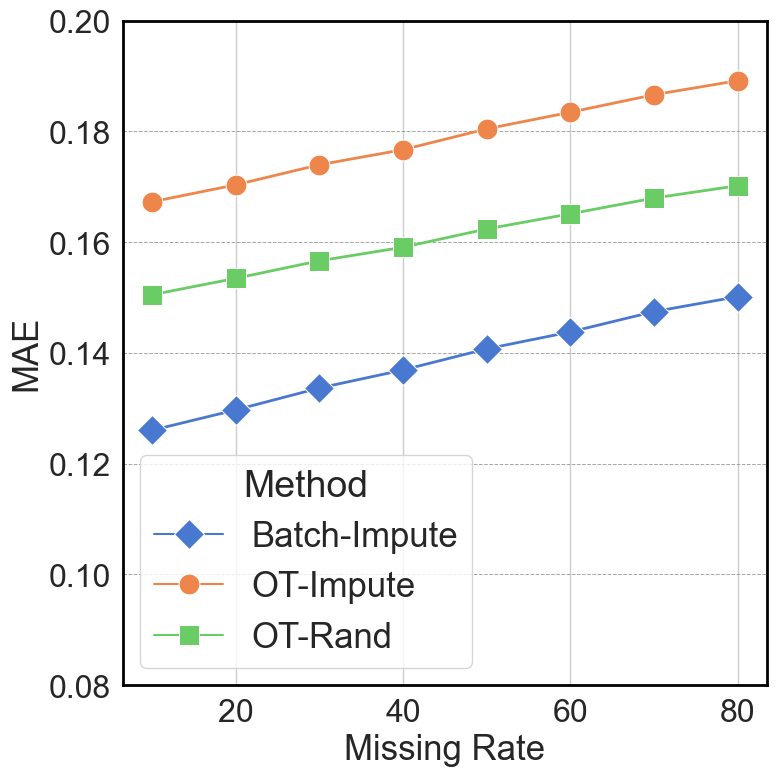

Saved plot for budget 20%


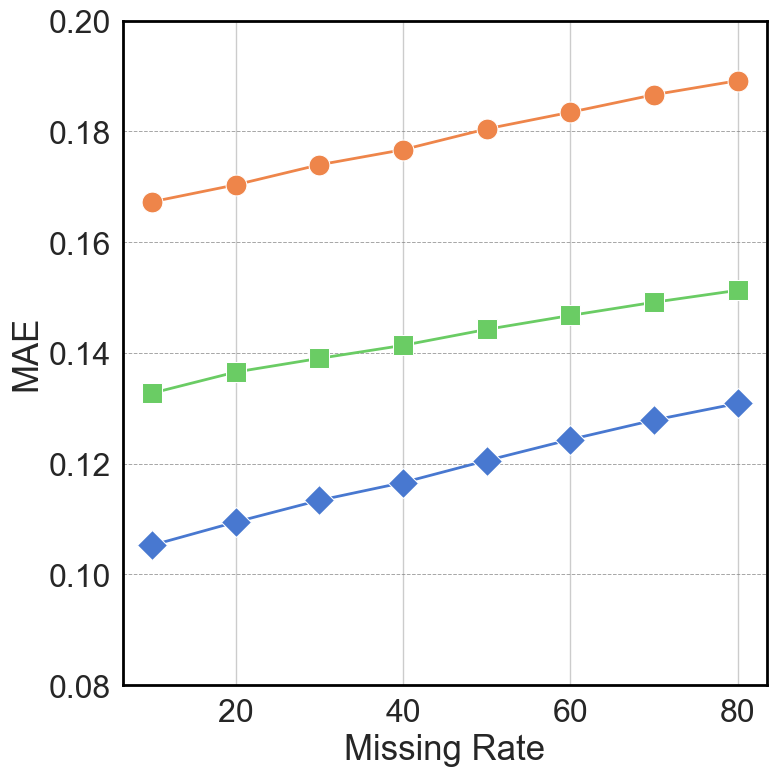

Saved plot for budget 30%


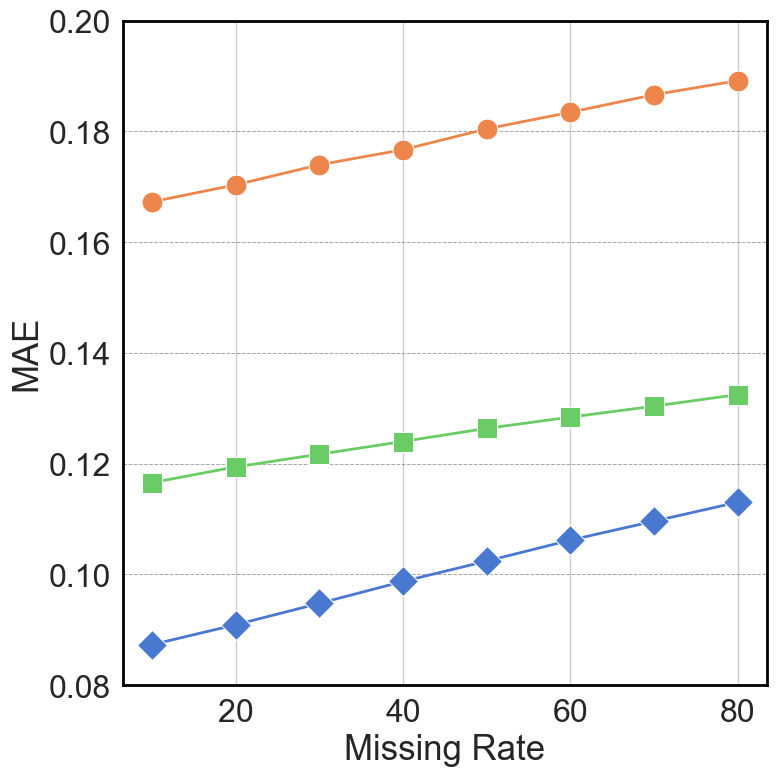

All plots generated successfully.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_results_mar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.08
y_max = 0.20

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

MNAR

Plotting results...
Saved plot for budget 10%


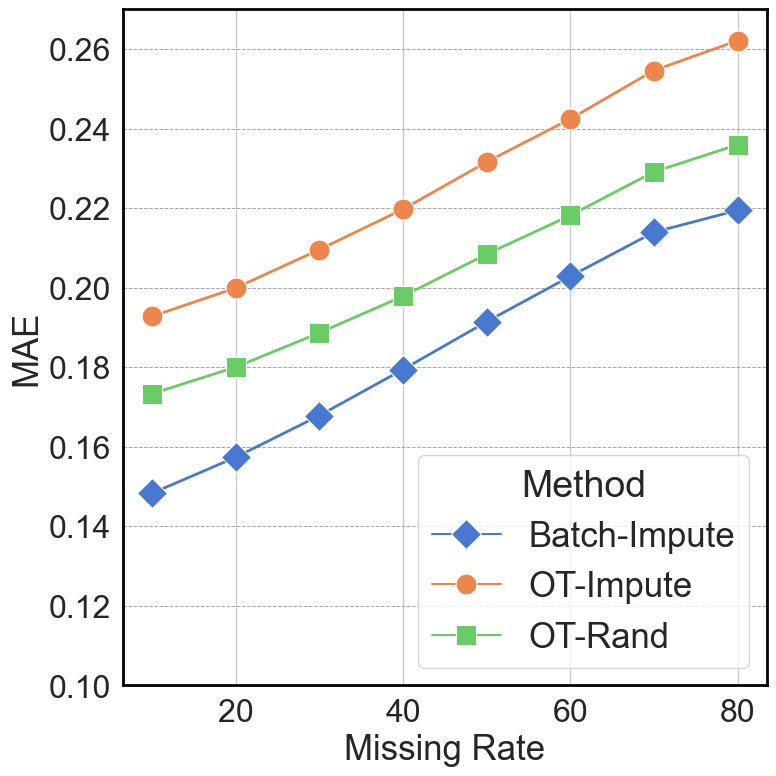

Saved plot for budget 20%


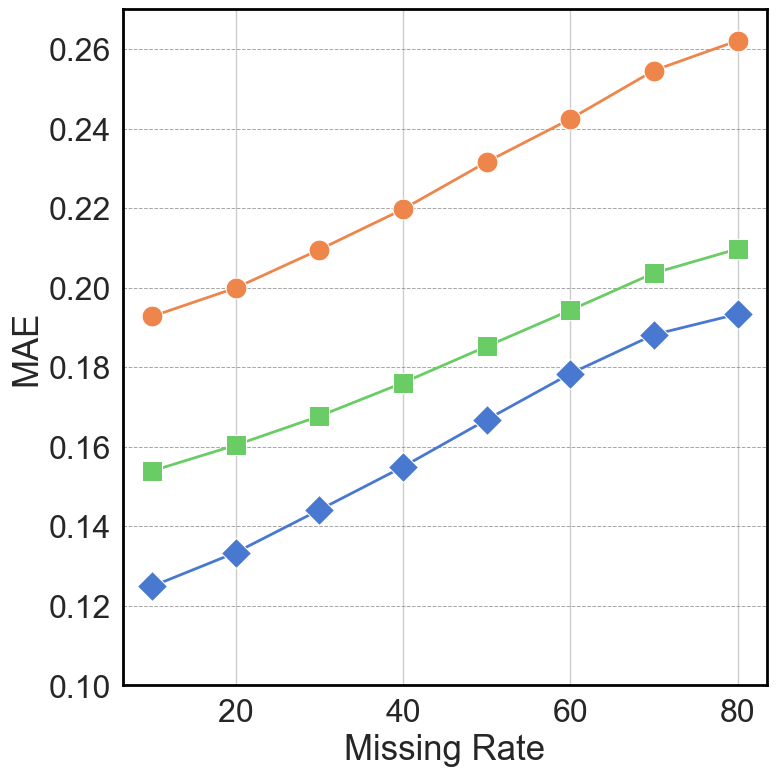

Saved plot for budget 30%


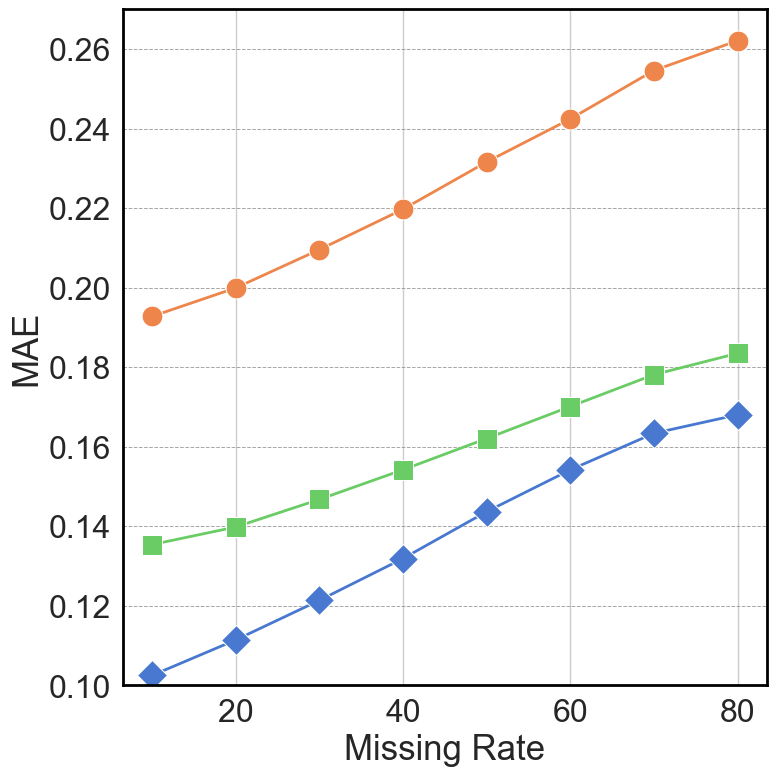

All plots generated successfully.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_results_mnar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.10
y_max = 0.27

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MNAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

### Base Comparision

MCAR

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_26664\2065086437.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.lineplot(


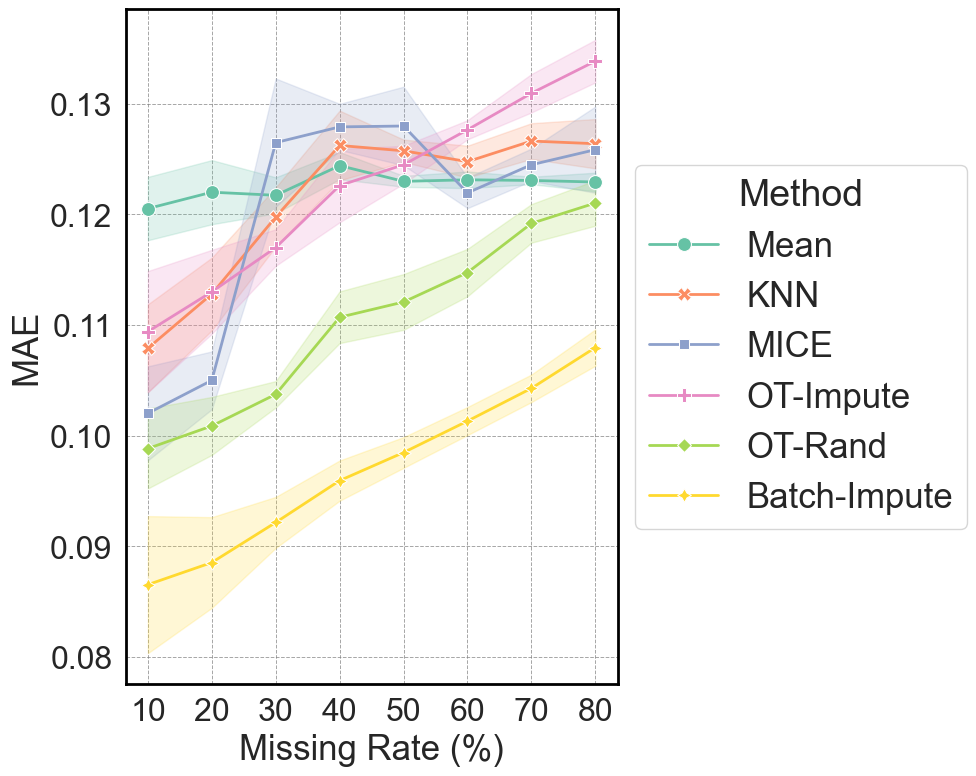

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_mae_diabetic = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_mae_base_comparison_mcar_budget01_allruns.csv")

# Group by method and missing rate
grouped_mae = df_mae_diabetic.groupby(["MissingRate(%)", "Method"])["MAE"].agg(["mean", "std"]).reset_index()

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2", n_colors=grouped_mae["Method"].nunique())

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 10

# Create line plot
plt.figure(figsize=(10, 8))
ax = sns.lineplot(
    data=df_mae_diabetic,
    x="MissingRate(%)",
    y="MAE",
    hue="Method",
    style="Method",
    markers=True,
    dashes=False,
    err_style="band",
    ci="sd",  # shaded band = ± standard deviation
    palette=palette,
    linewidth=line_width,
    markersize=marker_size
)

# === Axis labels and ticks ===
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize, labelpad=5)
plt.ylabel("MAE", fontsize=y_label_fontsize, labelpad=5)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and border ===
plt.grid(True, linestyle='--', color='gray', linewidth=0.7, alpha=0.7)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2)

# === Legend ===
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

# Save and show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAE_vs_MissingRate_MCAR.pdf", format="pdf", bbox_inches="tight")
plt.show()


MAR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_mae_diabetic = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_mae_base_comparison_mar_budget01_allruns.csv")

# Group by method and missing rate
grouped_mae = df_mae_diabetic.groupby(["MissingRate(%)", "Method"])["MAE"].agg(["mean", "std"]).reset_index()

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2", n_colors=grouped_mae["Method"].nunique())

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 10

# Create line plot
plt.figure(figsize=(10, 8))
ax = sns.lineplot(
    data=df_mae_diabetic,
    x="MissingRate(%)",
    y="MAE",
    hue="Method",
    style="Method",
    markers=True,
    dashes=False,
    err_style="band",
    ci="sd",  # shaded band = ± standard deviation
    palette=palette,
    linewidth=line_width,
    markersize=marker_size
)

# === Axis labels and ticks ===
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize, labelpad=5)
plt.ylabel("MAE", fontsize=y_label_fontsize, labelpad=5)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and border ===
plt.grid(True, linestyle='--', color='gray', linewidth=0.7, alpha=0.7)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2)

# === Legend ===
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

# Save and show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAE_vs_MissingRate_MAR.pdf", format="pdf", bbox_inches="tight")
plt.show()


MNAR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_mae_diabetic = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_mae_base_comparison_mnar_budget01_allruns.csv")

# Group by method and missing rate
grouped_mae = df_mae_diabetic.groupby(["MissingRate(%)", "Method"])["MAE"].agg(["mean", "std"]).reset_index()

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2", n_colors=grouped_mae["Method"].nunique())

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 10

# Create line plot
plt.figure(figsize=(10, 8))
ax = sns.lineplot(
    data=df_mae_diabetic,
    x="MissingRate(%)",
    y="MAE",
    hue="Method",
    style="Method",
    markers=True,
    dashes=False,
    err_style="band",
    ci="sd",  # shaded band = ± standard deviation
    palette=palette,
    linewidth=line_width,
    markersize=marker_size
)

# === Axis labels and ticks ===
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize, labelpad=5)
plt.ylabel("MAE", fontsize=y_label_fontsize, labelpad=5)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and border ===
plt.grid(True, linestyle='--', color='gray', linewidth=0.7, alpha=0.7)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2)

# === Legend ===
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

# Save and show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAE_vs_MissingRate_MNAR.pdf", format="pdf", bbox_inches="tight")
plt.show()


### MAE VS Dropout Noise

MCAR

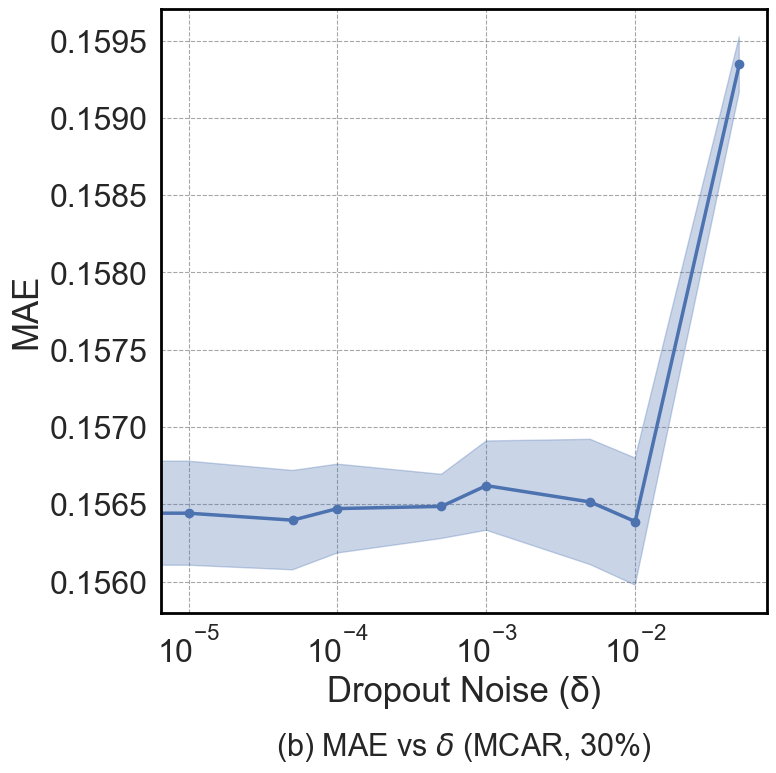

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatterMathtext

# Load the CSV
df_dropout = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MCAR_DropoutNoise_MAE_Results.csv")
df_dropout["DropoutNoise"] = pd.to_numeric(df_dropout["DropoutNoise"], errors='coerce')
df_dropout["MAE"] = pd.to_numeric(df_dropout["MAE"], errors='coerce')
df_dropout = df_dropout.dropna(subset=["DropoutNoise", "MAE"])

# Dropout values to include
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05]

# Filter and compute mean + std
df_line = (
    df_dropout[df_dropout["DropoutNoise"].isin(dropOutNoises)]
    .groupby("DropoutNoise")["MAE"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("DropoutNoise")
)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 8))

# Line + shaded area
plt.plot(
    df_line["DropoutNoise"], df_line["mean"],
    marker='o', color="#4c72b0", linewidth=2.5, markersize=6
)
plt.fill_between(
    df_line["DropoutNoise"],
    df_line["mean"] - df_line["std"],
    df_line["mean"] + df_line["std"],
    alpha=0.3,
    color="#4c72b0"
)

# Log scale and scientific ticks
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(LogFormatterMathtext())

# Labels
plt.xlabel("Dropout Noise (δ)", fontsize=25, labelpad=5)
plt.ylabel("MAE", fontsize=25, labelpad=5)

# Ticks and rotation
plt.xticks(fontsize=23, rotation=0)
plt.yticks(fontsize=23)

# Grid and border
plt.grid(True, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)


plt.title(r"(b) MAE vs $\delta$ (MCAR, 30%)", fontsize=22, y=-0.25)

# Save + show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MCAR_DropoutNoise_LogPlot.pdf", bbox_inches='tight')
plt.show()


MAR

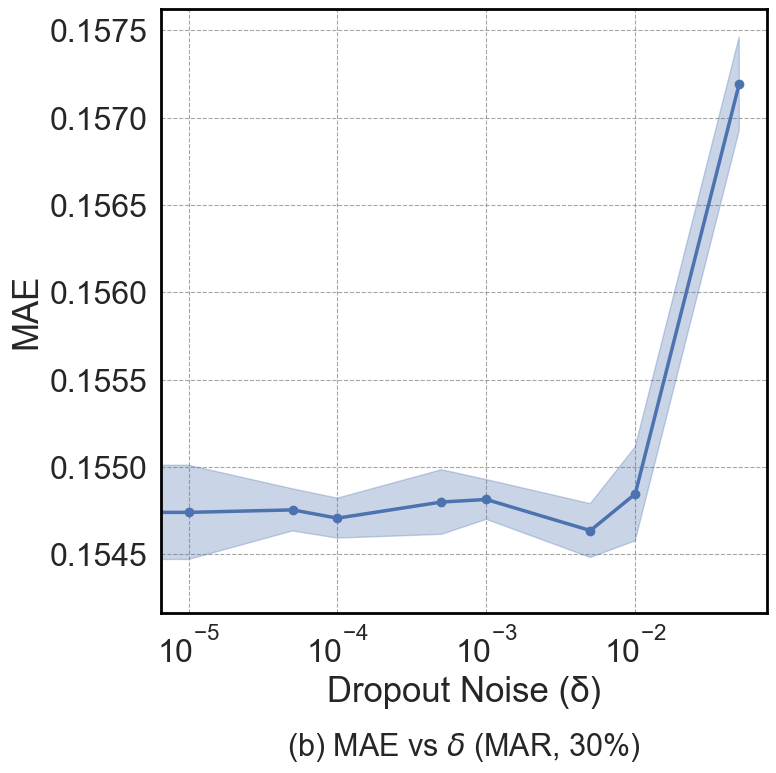

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatterMathtext

# Load the CSV
df_dropout = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MAR_DropoutNoise_MAE_Results.csv")
df_dropout["DropoutNoise"] = pd.to_numeric(df_dropout["DropoutNoise"], errors='coerce')
df_dropout["MAE"] = pd.to_numeric(df_dropout["MAE"], errors='coerce')
df_dropout = df_dropout.dropna(subset=["DropoutNoise", "MAE"])

# Dropout values to include
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05]

# Filter and compute mean + std
df_line = (
    df_dropout[df_dropout["DropoutNoise"].isin(dropOutNoises)]
    .groupby("DropoutNoise")["MAE"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("DropoutNoise")
)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 8))

# Line + shaded area
plt.plot(
    df_line["DropoutNoise"], df_line["mean"],
    marker='o', color="#4c72b0", linewidth=2.5, markersize=6
)
plt.fill_between(
    df_line["DropoutNoise"],
    df_line["mean"] - df_line["std"],
    df_line["mean"] + df_line["std"],
    alpha=0.3,
    color="#4c72b0"
)

# Log scale and scientific ticks
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(LogFormatterMathtext())

# Labels
plt.xlabel("Dropout Noise (δ)", fontsize=25, labelpad=5)
plt.ylabel("MAE", fontsize=25, labelpad=5)

# Ticks and rotation
plt.xticks(fontsize=23, rotation=0)
plt.yticks(fontsize=23)

# Grid and border
plt.grid(True, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)


plt.title(r"(b) MAE vs $\delta$ (MAR, 30%)", fontsize=22, y=-0.25)

# Save + show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAR_DropoutNoise_LogPlot.pdf", bbox_inches='tight')
plt.show()


MNAR

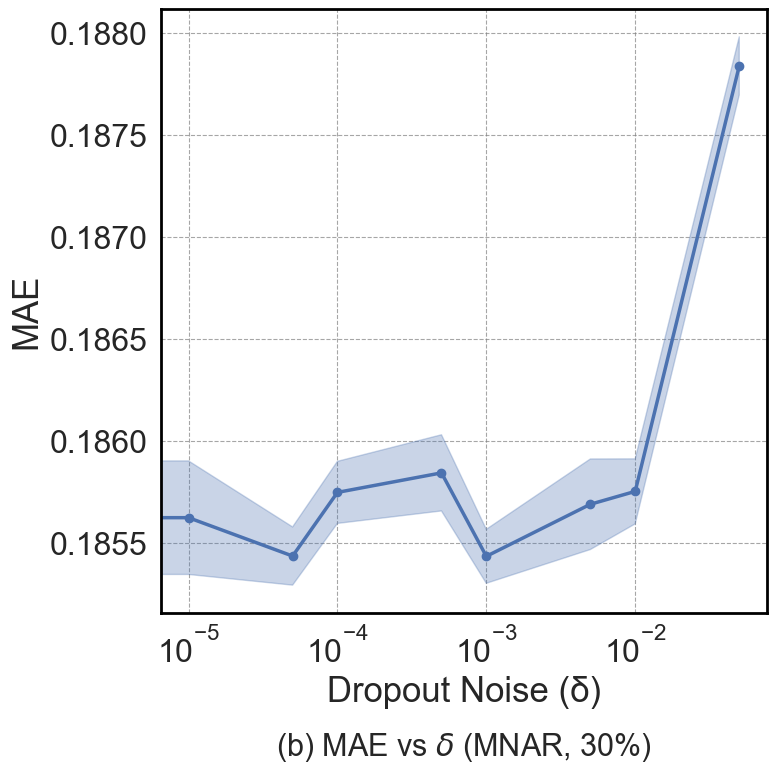

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatterMathtext

# Load the CSV
df_dropout = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MNAR_DropoutNoise_MAE_Results.csv")
df_dropout["DropoutNoise"] = pd.to_numeric(df_dropout["DropoutNoise"], errors='coerce')
df_dropout["MAE"] = pd.to_numeric(df_dropout["MAE"], errors='coerce')
df_dropout = df_dropout.dropna(subset=["DropoutNoise", "MAE"])

# Dropout values to include
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05]

# Filter and compute mean + std
df_line = (
    df_dropout[df_dropout["DropoutNoise"].isin(dropOutNoises)]
    .groupby("DropoutNoise")["MAE"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("DropoutNoise")
)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 8))

# Line + shaded area
plt.plot(
    df_line["DropoutNoise"], df_line["mean"],
    marker='o', color="#4c72b0", linewidth=2.5, markersize=6
)
plt.fill_between(
    df_line["DropoutNoise"],
    df_line["mean"] - df_line["std"],
    df_line["mean"] + df_line["std"],
    alpha=0.3,
    color="#4c72b0"
)

# Log scale and scientific ticks
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(LogFormatterMathtext())

# Labels
plt.xlabel("Dropout Noise (δ)", fontsize=25, labelpad=5)
plt.ylabel("MAE", fontsize=25, labelpad=5)

# Ticks and rotation
plt.xticks(fontsize=23, rotation=0)
plt.yticks(fontsize=23)

# Grid and border
plt.grid(True, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)


plt.title(r"(b) MAE vs $\delta$ (MNAR, 30%)", fontsize=22, y=-0.25)

# Save + show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MNAR_DropoutNoise_LogPlot.pdf", bbox_inches='tight')
plt.show()


### MAE VS Missing Rate OT-Impute, OT-Rand, Batch-Impute, BatchOP-Impute 

MCAR

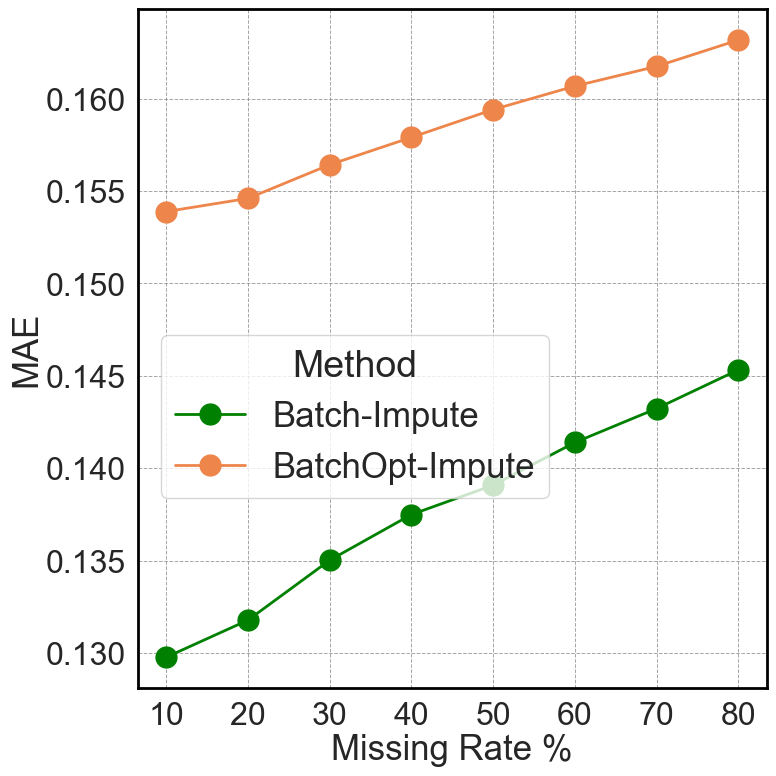

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV ===
df_mar_mae = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MCAR_OPT_Results_MAE.csv")

# === Extract values ===
missing_rates = df_mar_mae["MissingRate"].values
results_mar_opt = {
    "Batch-Impute": df_mar_mae["Batch-Impute"].values,
    "BatchOpt-Impute": df_mar_mae["BatchOpt-Impute"].values
}

# === Plot styling ===
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# === Create figure ===
plt.figure(figsize=(8, 8))

# Plot: Batch-Impute
plt.plot(missing_rates, results_mar_opt["Batch-Impute"],
         label="Batch-Impute",
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

# Plot: BatchOpt-Impute
plt.plot(missing_rates, results_mar_opt["BatchOpt-Impute"],
         label="BatchOpt-Impute",
         marker='o', color=palette[1], linewidth=line_width, markersize=marker_size)

# === Axis and Labels ===
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize, labelpad=2, fontweight='regular')
plt.ylabel("MAE", fontsize=y_label_fontsize, labelpad=2, fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and Border ===
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)

# === Legend ===
plt.legend(title="Method", fontsize=legend_label_fontsize,
           title_fontsize=legend_title_fontsize, loc="center left",
           bbox_to_anchor=(0.01, 0.4), frameon=True)

# === Save and Show ===
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MCAR_OptComparision_MAE.pdf", format="pdf", bbox_inches='tight')
plt.show()


MAR

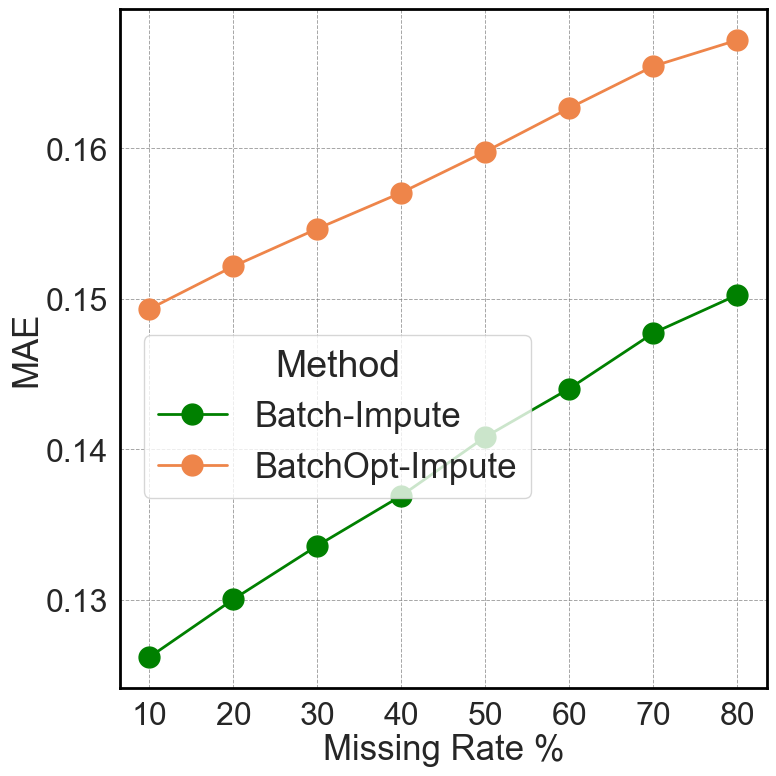

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV ===
df_mar_mae = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MAR_OPT_Results_MAE.csv")

# === Extract values ===
missing_rates = df_mar_mae["MissingRate"].values
results_mar_opt = {
    "Batch-Impute": df_mar_mae["Batch-Impute"].values,
    "BatchOpt-Impute": df_mar_mae["BatchOpt-Impute"].values
}

# === Plot styling ===
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# === Create figure ===
plt.figure(figsize=(8, 8))

# Plot: Batch-Impute
plt.plot(missing_rates, results_mar_opt["Batch-Impute"],
         label="Batch-Impute",
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

# Plot: BatchOpt-Impute
plt.plot(missing_rates, results_mar_opt["BatchOpt-Impute"],
         label="BatchOpt-Impute",
         marker='o', color=palette[1], linewidth=line_width, markersize=marker_size)

# === Axis and Labels ===
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize, labelpad=2, fontweight='regular')
plt.ylabel("MAE", fontsize=y_label_fontsize, labelpad=2, fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and Border ===
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)

# === Legend ===
plt.legend(title="Method", fontsize=legend_label_fontsize,
           title_fontsize=legend_title_fontsize, loc="center left",
           bbox_to_anchor=(0.01, 0.4), frameon=True)

# === Save and Show ===
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAR_OptComparision_MAE.pdf", format="pdf", bbox_inches='tight')
plt.show()


MNAR

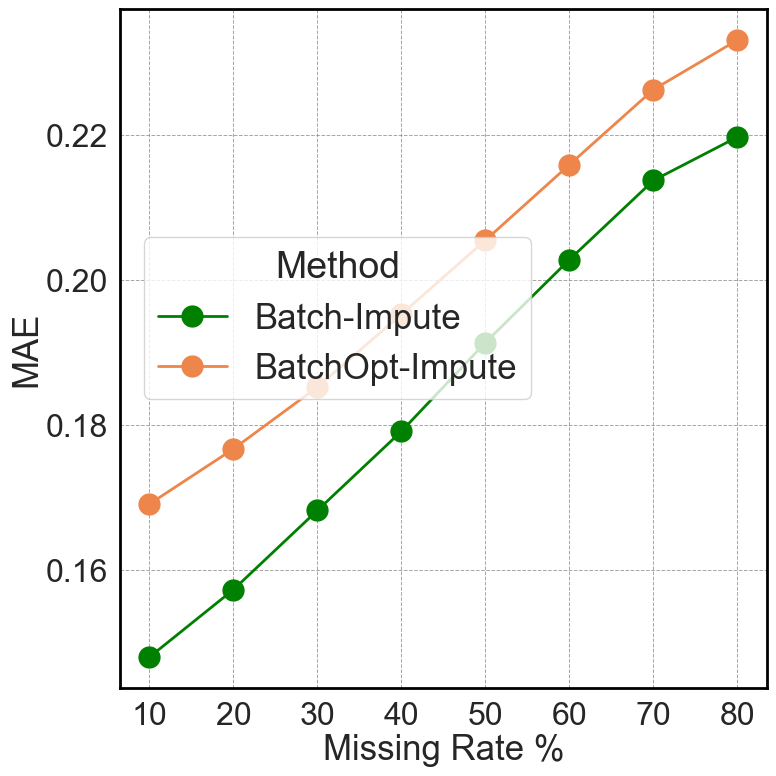

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV ===
df_mar_mae = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MNAR_OPT_Results_MAE.csv")

# === Extract values ===
missing_rates = df_mar_mae["MissingRate"].values
results_mar_opt = {
    "Batch-Impute": df_mar_mae["Batch-Impute"].values,
    "BatchOpt-Impute": df_mar_mae["BatchOpt-Impute"].values
}

# === Plot styling ===
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# === Create figure ===
plt.figure(figsize=(8, 8))

# Plot: Batch-Impute
plt.plot(missing_rates, results_mar_opt["Batch-Impute"],
         label="Batch-Impute",
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

# Plot: BatchOpt-Impute
plt.plot(missing_rates, results_mar_opt["BatchOpt-Impute"],
         label="BatchOpt-Impute",
         marker='o', color=palette[1], linewidth=line_width, markersize=marker_size)

# === Axis and Labels ===
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize, labelpad=2, fontweight='regular')
plt.ylabel("MAE", fontsize=y_label_fontsize, labelpad=2, fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and Border ===
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)

# === Legend ===
plt.legend(title="Method", fontsize=legend_label_fontsize,
           title_fontsize=legend_title_fontsize, loc="lower left",
           bbox_to_anchor=(0.01, 0.4), frameon=True)

# === Save and Show ===
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MNAR_OptComparision_MAE.pdf", format="pdf", bbox_inches='tight')
plt.show()


### Runtime VS Missing Rate Batch-Impute and BatchOpt-Impute

MCAR

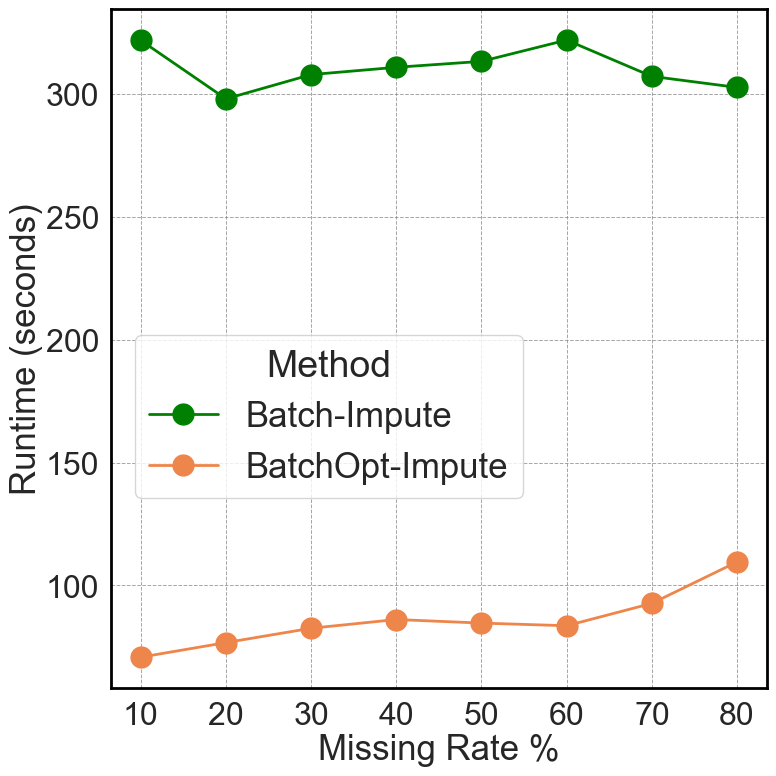

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV ===
df_mar_time = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MCAR_OPT_Results_Time.csv")

# === Extract values ===
missing_rates = df_mar_time["MissingRate"].values
results_time_mar = {
    "Batch-Impute": df_mar_time["Batch-Impute"].values,
    "BatchOpt-Impute": df_mar_time["BatchOpt-Impute"].values
}

# === Plot styling ===
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# === Create figure ===
plt.figure(figsize=(8, 8))

# Plot: Batch-Impute
plt.plot(missing_rates, results_time_mar["Batch-Impute"],
         label="Batch-Impute",
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

# Plot: BatchOpt-Impute
plt.plot(missing_rates, results_time_mar["BatchOpt-Impute"],
         label="BatchOpt-Impute",
         marker='o', color=palette[1], linewidth=line_width, markersize=marker_size)

# === Axis and Labels ===
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize, labelpad=2, fontweight='regular')
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize, labelpad=2, fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and Border ===
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)

# === Legend ===
plt.legend(title="Method", fontsize=legend_label_fontsize,
           title_fontsize=legend_title_fontsize, loc="center left",
           bbox_to_anchor=(0.01, 0.4), frameon=True)

# === Save and Show ===
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MCAR_OptComparision_Time.pdf", format="pdf", bbox_inches='tight')
plt.show()


MAR

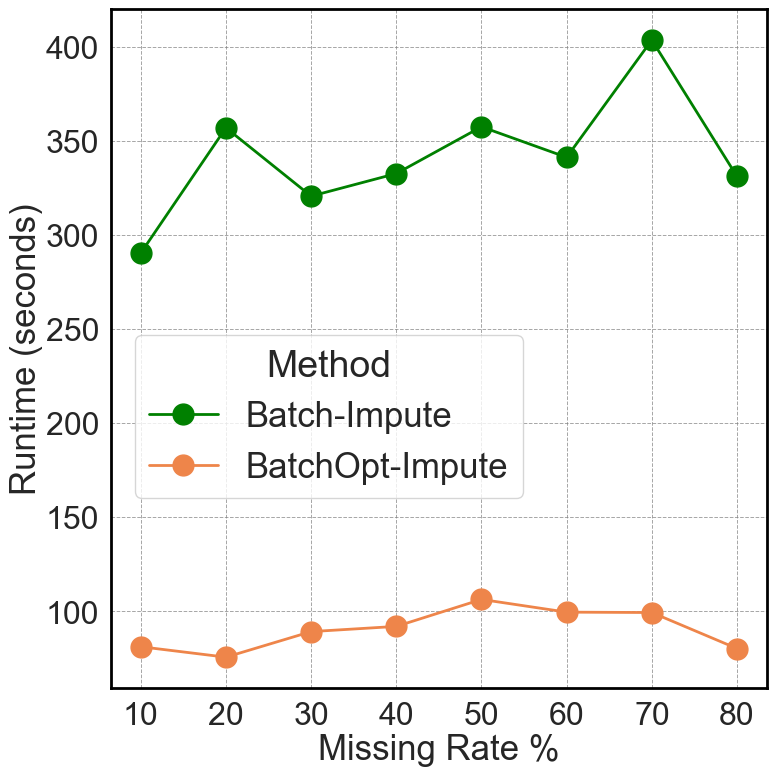

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV ===
df_mar_time = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MAR_OPT_Results_Time.csv")

# === Extract values ===
missing_rates = df_mar_time["MissingRate"].values
results_time_mar = {
    "Batch-Impute": df_mar_time["Batch-Impute"].values,
    "BatchOpt-Impute": df_mar_time["BatchOpt-Impute"].values
}

# === Plot styling ===
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# === Create figure ===
plt.figure(figsize=(8, 8))

# Plot: Batch-Impute
plt.plot(missing_rates, results_time_mar["Batch-Impute"],
         label="Batch-Impute",
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

# Plot: BatchOpt-Impute
plt.plot(missing_rates, results_time_mar["BatchOpt-Impute"],
         label="BatchOpt-Impute",
         marker='o', color=palette[1], linewidth=line_width, markersize=marker_size)

# === Axis and Labels ===
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize, labelpad=2, fontweight='regular')
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize, labelpad=2, fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and Border ===
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)

# === Legend ===
plt.legend(title="Method", fontsize=legend_label_fontsize,
           title_fontsize=legend_title_fontsize, loc="center left",
           bbox_to_anchor=(0.01, 0.4), frameon=True)

# === Save and Show ===
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MAR_OptComparision_Time.pdf", format="pdf", bbox_inches='tight')
plt.show()


MNAR

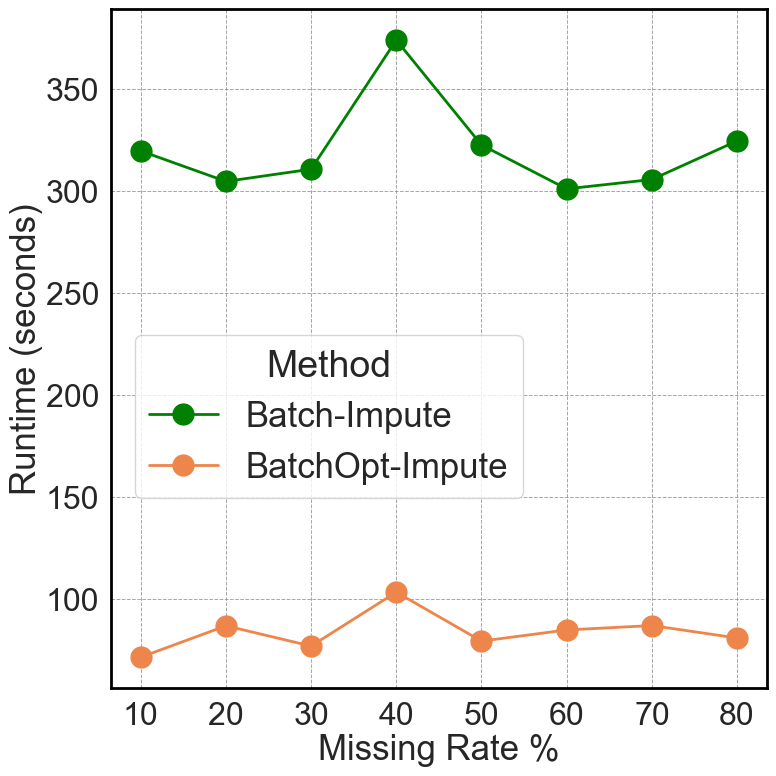

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV ===
df_mar_time = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_MNAR_OPT_Results_Time.csv")

# === Extract values ===
missing_rates = df_mar_time["MissingRate"].values
results_time_mar = {
    "Batch-Impute": df_mar_time["Batch-Impute"].values,
    "BatchOpt-Impute": df_mar_time["BatchOpt-Impute"].values
}

# === Plot styling ===
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Font and marker settings
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# === Create figure ===
plt.figure(figsize=(8, 8))

# Plot: Batch-Impute
plt.plot(missing_rates, results_time_mar["Batch-Impute"],
         label="Batch-Impute",
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

# Plot: BatchOpt-Impute
plt.plot(missing_rates, results_time_mar["BatchOpt-Impute"],
         label="BatchOpt-Impute",
         marker='o', color=palette[1], linewidth=line_width, markersize=marker_size)

# === Axis and Labels ===
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize, labelpad=2, fontweight='regular')
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize, labelpad=2, fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# === Grid and Border ===
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)

# === Legend ===
plt.legend(title="Method", fontsize=legend_label_fontsize,
           title_fontsize=legend_title_fontsize, loc="center left",
           bbox_to_anchor=(0.01, 0.4), frameon=True)

# === Save and Show ===
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_MNAR_OptComparision_Time.pdf", format="pdf", bbox_inches='tight')
plt.show()


### MAE VS Number of Iteration for budget 0.1, 0.2, 0.3 (Iter-Impute)

MCAR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MCAR.csv")

# Set plot style and font sizes
sns.set(style="whitegrid", font_scale=1.2)
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 20
marker_size = 12
line_width = 3

# Define colors and markers
palette = sns.color_palette("Set2", df['BudgetFraction'].nunique())
markers = ['o', 's', 'D', '^', 'v']

# Create the plot
plt.figure(figsize=(8, 8))

for i, (budget, subset) in enumerate(df.groupby('BudgetFraction')):
    plt.plot(
        subset['k'], subset['MAE'],
        marker=markers[i % len(markers)],
        label=f"{budget:.2f}",
        linewidth=line_width,
        markersize=marker_size,
        color=palette[i]
    )

# Axis labels and ticks
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plt.grid(True, linestyle='--', linewidth=0.7, color='gray', alpha=0.7)

# Legend
plt.legend(
    title="Budget",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

# Final layout
plt.tight_layout()

# Save the plot as PDF
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_iterative_MAE_vs_k_MCAR.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.show()


MAR

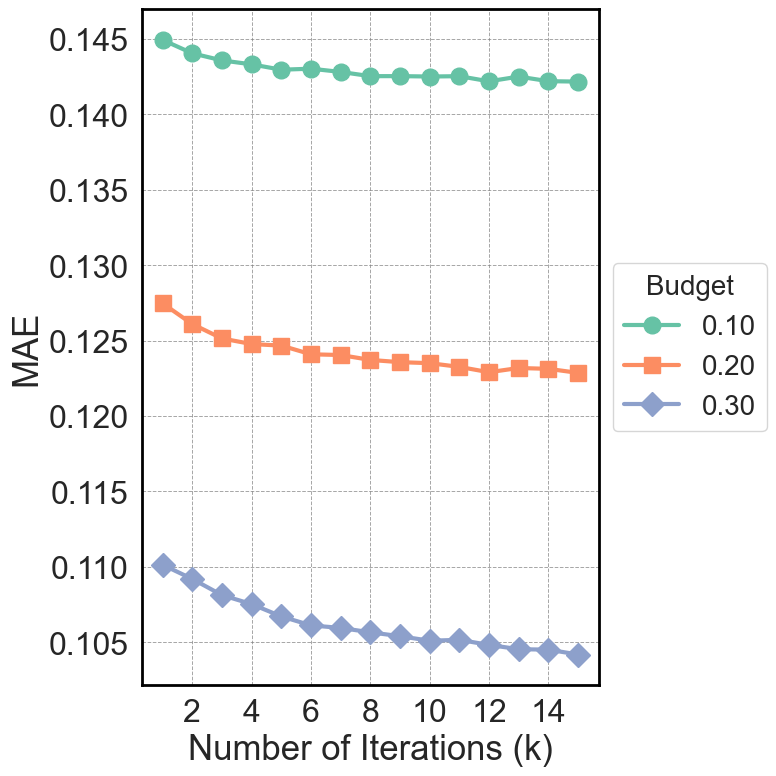

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MAR.csv")

# Set plot style and font sizes
sns.set(style="whitegrid", font_scale=1.2)
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 20
marker_size = 12
line_width = 3

# Define colors and markers
palette = sns.color_palette("Set2", df['BudgetFraction'].nunique())
markers = ['o', 's', 'D', '^', 'v']

# Create the plot
plt.figure(figsize=(8, 8))

for i, (budget, subset) in enumerate(df.groupby('BudgetFraction')):
    plt.plot(
        subset['k'], subset['MAE'],
        marker=markers[i % len(markers)],
        label=f"{budget:.2f}",
        linewidth=line_width,
        markersize=marker_size,
        color=palette[i]
    )

# Axis labels and ticks
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plt.grid(True, linestyle='--', linewidth=0.7, color='gray', alpha=0.7)

# Legend
plt.legend(
    title="Budget",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

# Final layout
plt.tight_layout()

# Save the plot as PDF
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_iterative_MAE_vs_k_MAR.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.show()


MNAR

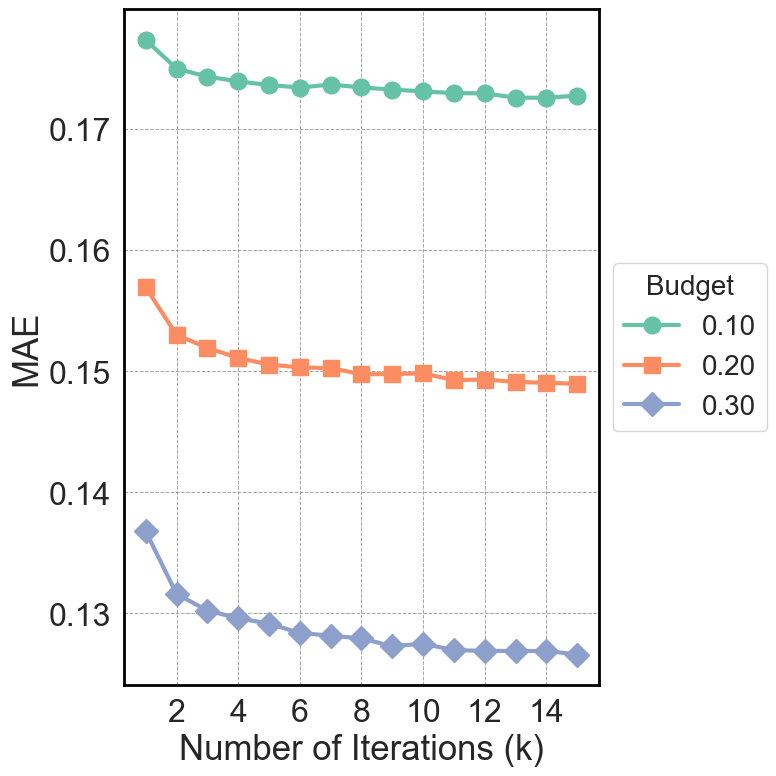

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MNAR.csv")

# Set plot style and font sizes
sns.set(style="whitegrid", font_scale=1.2)
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 20
marker_size = 12
line_width = 3

# Define colors and markers
palette = sns.color_palette("Set2", df['BudgetFraction'].nunique())
markers = ['o', 's', 'D', '^', 'v']

# Create the plot
plt.figure(figsize=(8, 8))

for i, (budget, subset) in enumerate(df.groupby('BudgetFraction')):
    plt.plot(
        subset['k'], subset['MAE'],
        marker=markers[i % len(markers)],
        label=f"{budget:.2f}",
        linewidth=line_width,
        markersize=marker_size,
        color=palette[i]
    )

# Axis labels and ticks
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plt.grid(True, linestyle='--', linewidth=0.7, color='gray', alpha=0.7)

# Legend
plt.legend(
    title="Budget",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
)

# Final layout
plt.tight_layout()

# Save the plot as PDF
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_iterative_MAE_vs_k_MNAR.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.show()


### Runtime vs Number of Iteration Iter-Impute

MCAR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MCAR.csv")

# Filter for budget = 0.1
df_budget_01 = df[df["BudgetFraction"] == 0.1]

# Set the Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25

# Plot
plt.figure(figsize=(8, 8))
plt.plot(
    df_budget_01["k"],
    df_budget_01["Runtime"],
    marker='o',
    linewidth=3,
    markersize=10,
    color="#2ca02c",  # green
    label="Budget = 0.1"
)

# Axis labels
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize)

# Ticks
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and border styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Legend
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="upper left",
    frameon=True
)

# Layout and save
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_iterative_Runtime_vs_k_MCAR_budget01.pdf", format="pdf", bbox_inches='tight')
plt.show()


MAR

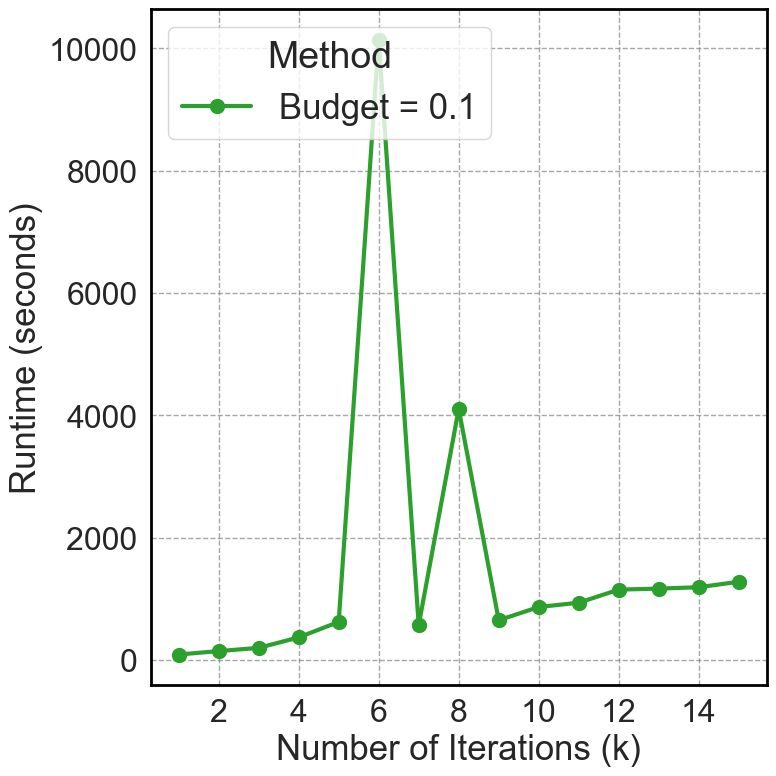

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MAR.csv")

# Filter for budget = 0.1
df_budget_01 = df[df["BudgetFraction"] == 0.1]

# Set the Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25

# Plot
plt.figure(figsize=(8, 8))
plt.plot(
    df_budget_01["k"],
    df_budget_01["Runtime"],
    marker='o',
    linewidth=3,
    markersize=10,
    color="#2ca02c",  # green
    label="Budget = 0.1"
)

# Axis labels
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize)

# Ticks
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and border styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Legend
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="upper left",
    frameon=True
)

# Layout and save
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_iterative_Runtime_vs_k_MAR_budget01.pdf", format="pdf", bbox_inches='tight')
plt.show()


MNAR

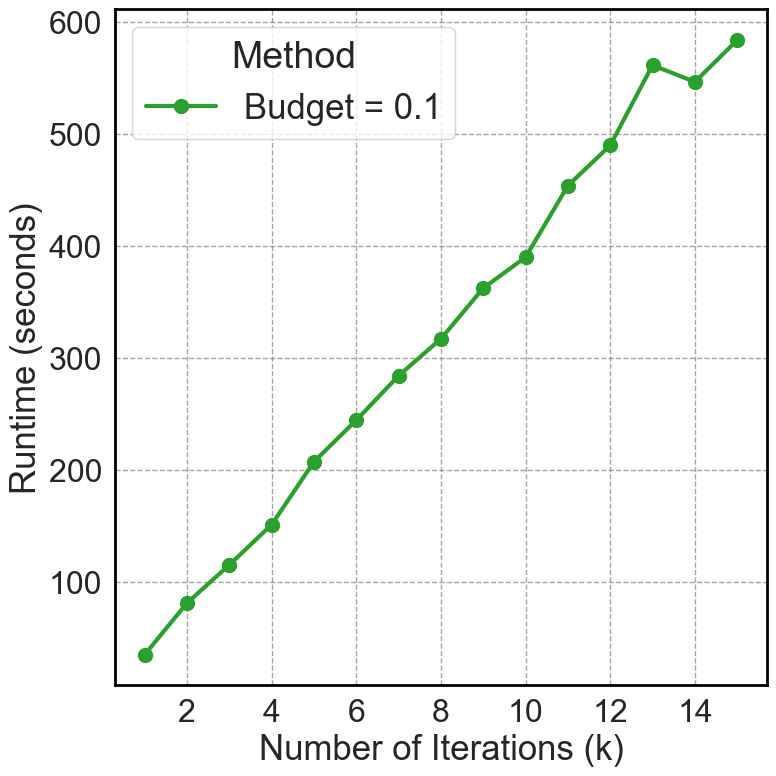

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Diabetic_iterative_activeFix_results_MNAR.csv")

# Filter for budget = 0.1
df_budget_01 = df[df["BudgetFraction"] == 0.1]

# Set the Seaborn style
sns.set(style="whitegrid", font_scale=1.2)

# Font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25

# Plot
plt.figure(figsize=(8, 8))
plt.plot(
    df_budget_01["k"],
    df_budget_01["Runtime"],
    marker='o',
    linewidth=3,
    markersize=10,
    color="#2ca02c",  # green
    label="Budget = 0.1"
)

# Axis labels
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize)

# Ticks
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and border styling
plt.grid(True, linestyle='--', color='gray', alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Legend
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="upper left",
    frameon=True
)

# Layout and save
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Diabetic_iterative_Runtime_vs_k_MNAR_budget01.pdf", format="pdf", bbox_inches='tight')
plt.show()
